In [63]:
import itertools as it
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import joblib

In [ ]:
# # Cargar el checkpoint
# checkpoint = joblib.load('estado_notebook_rl.joblib')
#
# # Restaurar todas las variables al espacio global
# globals().update(checkpoint)
#
# print("¡Estado del notebook restaurado correctamente!")

### Clase para encapsular los metodos de la resolución
#### Variables relevantes
* p_oil: Precio Petróleo
* q_liq: liquido extraído
* q_oil: petróleo extraido
* q_wat: agua extraída
* c_iny: costo de inyección
* c_wat: costo de disponibilidad de agua
* tita: factor que penaliza yacimentos depletados
* alpha: tasa de descuento

In [64]:
class WaterIny:
  def __init__(self, a, s, probas_wc, probas_np, p_oil, tita, alpha, np_max, np_res, wcs):
    self._a = a
    self._s = s
    self._probas_wc = probas_wc
    self._probas_np = probas_np
    self._p_oil = p_oil
    self._tita = tita
    self._alpha = alpha
    self._np_max = np_max
    self._np_res = np_res
    self._wcs = wcs
    ##### CONSTANTES DENTRO DE LA CLASE --> Las podemos sacar afuera tambien
    self._q_liq_opt = [20000, 100000, 180000]
    self._c_iny_opt = [8000, 10000, 15000]
    self._c_wat_disp = 1.5



  # Para una determinada acción, retorna la cantidad de líquido que se extraerá
  def q_liq(self, acc):
    '''Acepta "L", "M" o "H"'''
    if acc not in self._a:
      raise ValueError("Las acciones posibles son 'L', 'M' o 'H'")
    return self._q_liq_opt[self._a.index(acc)]

  # Para un determinado NP, devuelve el factor f
  def f(self, np):
    return 1 - self._tita * np / self._np_max

  # Para un estado y una acción, retorna la cantidad de petróleo que se extraerá
  def q_oil(self, estado, acc):
    return self.q_liq(acc) * (1 - estado[0]) * self.f(estado[1])

  # Calcula la cantidad de agua que se extraerá
  def q_wat(self, estado, acc):
    return self.q_liq(acc) - self.q_oil(estado, acc)

  # Calcula el costo de inyección
  def c_iny(self, acc):
    '''Acepta "L", "M" o "H"'''
    if acc not in self._a:
      raise ValueError("Las acciones posibles son 'L', 'M' o 'H'")
    return self._c_iny_opt[self._a.index(acc)]

  # Calcula el costo de disposición del agua a inyectar
  def c_wat(self, estado, acc):
    return self._c_wat_disp * self.q_wat(estado, acc)

  # Si se toma una determinada acción desde un estado determinado, cuales son las probabilidades de pasar a otros estados posibles
  def transicion(self, estado, acc):
    '''Acepta "L", "M" o "H"'''
    if acc not in self._a:
      raise ValueError("Las acciones posibles son 'L', 'M' o 'H'")
    # watercut
    wc = estado[0]
    proba_up = self._probas_wc[0][self._a.index(acc)]
    proba_down = self._probas_wc[1][self._a.index(acc)]
    if estado[0] == 0.8:
      prob_wc_next = [0, 1 - proba_up, proba_up]
    elif estado[0] == 1:
      prob_wc_next = [proba_down, 1 - proba_down, 0]
    else:
      prob_wc_next = [proba_down, 1 - proba_down - proba_up, proba_up]

    # np
    np = estado[1]
    proba_up = self._probas_np[self._wcs.index(estado[0])][[self._a.index(acc)]]
    prob_np_next = [1- proba_up, proba_up]

    return prob_wc_next, prob_np_next

  # Funcion recompensa
  def reward(self, estado, acc):
    return self._p_oil * self.q_oil(estado, acc) - self.c_iny(acc) - self.c_wat(estado, acc)

  # FUNCION VALOR
  # (estados, accion, valor)
  def valor(self, x, a, V):
    prob_wc_next, prob_np_next = self.transicion(x, a)
    v_esperado = 0

    for i, delta_wc in enumerate([-0.01, 0, 0.01]):
        wc_prime = round(x[0] + delta_wc, 2)
        if wc_prime not in self._wcs:
            continue
        for j, delta_np in enumerate([0, self._np_res]):  # asumiendo paso de 100 --> resolucion
            np_prime = x[1] + delta_np
            if np_prime > self._np_max:
                continue
            y = (wc_prime, np_prime)
            p = prob_wc_next[i] * prob_np_next[j]
            v_esperado += p * V.get(y, 0)

    return self.reward(x, a) + self._alpha * v_esperado

  # ARGMAX --> decisión greedy sobre la funcion de valor
  def argmax_value(self, x, V):
    valores = {}
    for a in self._a:
        valores[a] = self.valor(x, a, V)
    # devuelve el mayor valor para un estado considerando las 3 acciones posibles
    return max(valores, key=valores.get)

# g(x, a): genera muestra de transición (r, y)
  def transition_sample(self, x, a):
    prob_wc_next, prob_np_next = self.transicion(x, a)

    delta_wc = random.choices(population=[-0.01, 0, 0.01], weights=prob_wc_next, k=1)[0]
    delta_np = random.choices(population=[0, self._np_res], weights=prob_np_next, k=1)[0]

    wc_next = round(x[0] + delta_wc, 2)
    np_next = x[1] + delta_np

    # limitar valores extremos
    wc_next = min(max(wc_next, min(self._wcs)), max(self._wcs))
    np_next = min(np_next, self._np_max)

    y = (wc_next, np_next)
    r = self.reward(x, a)

    return r, y

### Parámetros para instanciar la clase
DeltaNP a partir del watercut y la acción tomada
- si wc es 0,8 --> proba de que np suba 100 unidades es [0.1, 0.2, 0.4]
- si wc es 0,85 --> proba de que np suba 100 unidades es [0.08, 0.15, 0.3]
- si wc es 0,9 --> proba de que np suba 100 unidades es [0.06, 0.1, 0.2]
- si wc es 0,95 --> proba de que np suba 100 unidades es [0.03, 0.05, 0.1]
- si wc es 1 --> proba de que np suba 100 unidades es [0, 0, 0]

In [65]:
# Constantes
p_oil = 60
tita = 0.3
max_np = 1000
np_resolution = 10
probas_wc = np.array(([0.1, 0.3, 0.7]
                      , [0.2, 0.1, 0]
                      ))

alpha = 0.95

# Acciones
a = ['L','M','H'] # Inyección Baja, Media, Alta

# Estados
s_wc = np.arange(0.8, 1.01, 0.01).round(2).tolist()
s_np = list(range(0,max_np+np_resolution,np_resolution))

s = list(it.product(s_wc, s_np))

In [66]:
def crear_matriz_probas_np(s_wc):
    # Crear matriz vacía con tamaño adecuado
    probas_np = np.zeros((len(s_wc), 3))

    # Definir los puntos conocidos (los 5 originales)
    puntos_conocidos = {
        0.80: [0.1, 0.2, 0.4],
        0.85: [0.08, 0.15, 0.3],
        0.90: [0.06, 0.1, 0.2],
        0.95: [0.03, 0.05, 0.1],
        1.00: [0, 0, 0]
    }

    # Llenar la matriz para todos los valores de watercut por interpolación lineal
    for i, wc in enumerate(s_wc):
        wc_rounded = round(wc, 2)  # Redondear para evitar errores de punto flotante

        if wc_rounded in puntos_conocidos:
            # Usar el valor exacto si está disponible
            probas_np[i] = puntos_conocidos[wc_rounded]
        else:
            # Encontrar los puntos conocidos más cercanos para interpolar
            wc_inferior = max([k for k in puntos_conocidos.keys() if k < wc_rounded])
            wc_superior = min([k for k in puntos_conocidos.keys() if k > wc_rounded])

            # Calcular peso para interpolación lineal
            peso = (wc_rounded - wc_inferior) / (wc_superior - wc_inferior)

            # Interpolar los valores para cada acción (L, M, H)
            for j in range(3):
                valor_inferior = puntos_conocidos[wc_inferior][j]
                valor_superior = puntos_conocidos[wc_superior][j]
                probas_np[i, j] = valor_inferior + peso * (valor_superior - valor_inferior)

    return probas_np

# Aplicar esta función para crear la nueva matriz de probabilidades
probas_np = crear_matriz_probas_np(s_wc)

### Instanciado y uso de la clase

In [67]:
modelo = WaterIny(
    a=a,
    s=s,
    probas_wc=probas_wc,
    probas_np=probas_np,
    p_oil=p_oil,
    tita=tita,
    alpha=alpha,
    np_max=max_np,
    np_res=np_resolution,
    wcs=s_wc
)

### Iteracion de valor

In [68]:
def iteracion_valor(modelo, epsilon=1e-4, max_iter=1000):
    V = {x: 0 for x in modelo._s}
    pi = {}

    for _ in range(max_iter):
        delta = 0
        V_new = V.copy()

        for x in modelo._s:
            valores_acciones = [modelo.valor(x, a, V) for a in modelo._a]
            V_new[x] = max(valores_acciones)
            delta = max(delta, abs(V_new[x] - V[x]))

        V = V_new

        if delta < epsilon:
            break

    for x in modelo._s:
        pi[x] = modelo.argmax_value(x, V)

    return V, pi

In [69]:
V_opt_valor, pi_opt_valor = iteracion_valor(modelo)

In [70]:
print('V_opt')
print(V_opt_valor)
print('pi_opt')
print(pi_opt_valor)

V_opt
{(0.8, 0): array([18066685.22857072]), (0.8, 10): array([17999956.94760398]), (0.8, 20): array([17933242.53570634]), (0.8, 30): array([17866536.39600217]), (0.8, 40): array([17799833.89107418]), (0.8, 50): array([17733132.42557721]), (0.8, 60): array([17666431.10439884]), (0.8, 70): array([17599729.78322058]), (0.8, 80): array([17533028.46204242]), (0.8, 90): array([17466327.14086436]), (0.8, 100): array([17399625.81968639]), (0.8, 110): array([17332924.49850851]), (0.8, 120): array([17266223.17733072]), (0.8, 130): array([17199521.856153]), (0.8, 140): array([17132820.53497538]), (0.8, 150): array([17066119.21379783]), (0.8, 160): array([16999417.89262036]), (0.8, 170): array([16932716.57144297]), (0.8, 180): array([16866015.25026567]), (0.8, 190): array([16799313.92908846]), (0.8, 200): array([16732612.60791134]), (0.8, 210): array([16665911.28673431]), (0.8, 220): array([16599209.96555738]), (0.8, 230): array([16532508.64438055]), (0.8, 240): array([16465807.32320381]), (0.8, 

### Iteracion de politicas

In [71]:
def mejorar_politica(V, modelo, s, a):
    """
    Dada una función valor V, mejora la política seleccionando la mejor acción en cada estado.
    """
    nueva_pi = {}
    for estado in s:
        mejor_accion = modelo.argmax_value(estado, V)
        nueva_pi[estado] = mejor_accion
    return nueva_pi

def evaluar_politica(modelo, politica, epsilon=1e-4, max_iter=1000):
    V = {x: 0 for x in modelo._s}
    for _ in range(max_iter):
        V_new = V.copy()
        delta = 0
        for x in modelo._s:
            a = politica[x]
            V_new[x] = modelo.valor(x, a, V)
            delta = max(delta, abs(V_new[x] - V[x]))
        V = V_new
        if delta < epsilon:
            break
    return V

def iteracion_de_politica(modelo, s, a, alpha, epsilon=1e-4, max_iter=1000):
    """
    Iteración de política usando iteración de valor como evaluación de política.
    """
    # Inicializamos política arbitraria (por ejemplo, todo "M")
    pi = {estado: 'H' for estado in s}

    for i in range(max_iter):
        # 1. Evaluamos la política actual (con value iteration fijo)
        V = evaluar_politica(modelo, pi, epsilon=epsilon, max_iter=max_iter)

       # 2. Mejoramos la política
        nueva_pi = mejorar_politica(V, modelo, s, a)

        # 3. Chequeamos convergencia
        if nueva_pi == pi:
            print(f"Convergió en {i} iteraciones.")
            break
        else:
            pi = nueva_pi

    return V, pi


In [72]:
V_opt_politica, pi_opt_politica = iteracion_de_politica(modelo, s, a, alpha)

Convergió en 4 iteraciones.


In [73]:
print('V_opt')
print(V_opt_politica)
print('pi_opt')
print(pi_opt_politica)

V_opt
{(0.8, 0): array([18066685.22859787]), (0.8, 10): array([17999956.94763681]), (0.8, 20): array([17933242.53574458]), (0.8, 30): array([17866536.39604558]), (0.8, 40): array([17799833.89112261]), (0.8, 50): array([17733132.42563053]), (0.8, 60): array([17666431.10445694]), (0.8, 70): array([17599729.78328334]), (0.8, 80): array([17533028.46210975]), (0.8, 90): array([17466327.14093615]), (0.8, 100): array([17399625.81976256]), (0.8, 110): array([17332924.49858897]), (0.8, 120): array([17266223.17741537]), (0.8, 130): array([17199521.85624178]), (0.8, 140): array([17132820.53506819]), (0.8, 150): array([17066119.21389459]), (0.8, 160): array([16999417.892721]), (0.8, 170): array([16932716.57154741]), (0.8, 180): array([16866015.25037381]), (0.8, 190): array([16799313.92920022]), (0.8, 200): array([16732612.60802663]), (0.8, 210): array([16665911.28685304]), (0.8, 220): array([16599209.96567944]), (0.8, 230): array([16532508.64450585]), (0.8, 240): array([16465807.32333226]), (0.8, 

### Q Learning

In [74]:
def q_learning(modelo, s, a, epsilon=1e-4, max_iter=100, init='zeros', verbose=False):
    """
    Q-learning con exploración epsilon-greedy.

    Args:
        modelo: instancia de WaterIny
        s: lista de estados
        a: lista de acciones ['L', 'M', 'H']
        epsilon: probabilidad de exploración
        max_iter: cantidad de episodios

    Returns:
        Q: diccionario con valores Q[(estado, accion)]
        pi_q: política derivada greedy sobre Q
    """
    random.seed(42)
    s_a_probados=0
    # Para cada valor del diccionario Q (Qhat) se tiene una tupla con el count y el valor hasta el momento
    Q = {key: [0,0] for key in it.product(s, a)} # Changed to list [0, 0]

    if init=='recorrido':
      for est, acc in it.product(s, a):
        recompensa, siguiente_estado = modelo.transition_sample(est, acc)
        # Actualización Q-learning
        max_q_siguiente = max(Q[(siguiente_estado, act)][1] for act in a)
        # Se agrega 1 a la cantidad de veces que se visitó la combinacion (estado accion)
        Q[(est, acc)][0] += 1
        # Gamma es decreciente con la forma 1/N, siendo N la cantidad de veces que se visitó la combinacion (estado accion)
        Q[(est, acc)][1] += (recompensa + max_q_siguiente - Q[(est, acc)][1])/Q[(est, acc)][0]


    for episodio in range(max_iter):
        estado = random.choice(s)

        if episodio in [max_iter/2, max_iter*9/10] and verbose:
          print(f"Progreso: {episodio/max_iter:.0%}  |  Estado-Acción recorridos: {s_a_probados}")

        while True:
            s_a_probados += 1
            # Política ε-greedy vs politica aleatoria --> Explotación vs Exploración
            if random.random() < epsilon:
                accion = random.choice(a)
            else:
                accion = max(a, key=lambda act: Q[(estado, act)][1])

            # Transición simulada
            recompensa, siguiente_estado = modelo.transition_sample(estado, accion)

            # Actualización Q-learning
            max_q_siguiente = max(Q[(siguiente_estado, act)][1] for act in a)
            # Se agrega 1 a la cantidad de veces que se visitó la combinacion (estado accion)
            Q[(estado, accion)][0] += 1
            # Gamma es decreciente con la forma 1/N, siendo N la cantidad de veces que se visitó la combinacion (estado accion)
            Q[(estado, accion)][1] += (recompensa + max_q_siguiente - Q[(estado, accion)][1])/Q[(estado, accion)][0]

            # Condición de fin de episodio
            if siguiente_estado[1] >= modelo._np_max:
                break

            estado = siguiente_estado

    # Derivar política greedy desde Q
    pi_q = dict()
    for estado in s:
        pi_q[estado] = max(a, key=lambda act: Q[(estado, act)][1]) # Added [1] to access the value

    return Q, pi_q

In [115]:
Q_opt_ql, pi_opt_ql = q_learning(modelo, s, a, epsilon=0.5, max_iter=30000, init='recorrido', verbose=True)

Progreso: 50%  |  Estado-Acción recorridos: 52675418
Progreso: 90%  |  Estado-Acción recorridos: 93070586


In [116]:
print('V_opt')
print(Q_opt_ql)
print('pi_opt')
print(pi_opt_ql)

V_opt
{((0.8, 0), 'L'): [1, 207999.99999999994], ((0.8, 0), 'M'): [2, 4883120.971414608], ((0.8, 0), 'H'): [5, 7478018.705752996], ((0.8, 10), 'L'): [8, 5503584.83265434], ((0.8, 10), 'M'): [7, 5461477.98521735], ((0.8, 10), 'H'): [22, 7397404.332487247], ((0.8, 20), 'L'): [7, 4848954.995718799], ((0.8, 20), 'M'): [2, 3457156.9858353725], ((0.8, 20), 'H'): [19, 8168344.163926703], ((0.8, 30), 'L'): [6, 5742334.519549166], ((0.8, 30), 'M'): [2, 4570287.4480029205], ((0.8, 30), 'H'): [10, 8087254.669730276], ((0.8, 40), 'L'): [7, 5249593.090673332], ((0.8, 40), 'M'): [13, 6413574.876010576], ((0.8, 40), 'H'): [13, 7942414.245512281], ((0.8, 50), 'L'): [4, 4759208.656730827], ((0.8, 50), 'M'): [4, 6551303.596554063], ((0.8, 50), 'H'): [23, 7691717.892700503], ((0.8, 60), 'L'): [10, 6816254.136428366], ((0.8, 60), 'M'): [6, 7370221.0250828015], ((0.8, 60), 'H'): [19, 8517558.49946175], ((0.8, 70), 'L'): [5, 6607254.006164916], ((0.8, 70), 'M'): [9, 7769824.554167048], ((0.8, 70), 'H'): [18

In [117]:
Q_opt_ql_zero, pi_opt_ql_zero = q_learning(modelo, s, a, epsilon=0.5, max_iter=30000, init='zeros', verbose=True)

Progreso: 50%  |  Estado-Acción recorridos: 51543215
Progreso: 90%  |  Estado-Acción recorridos: 91499999


In [118]:
print('V_opt')
print(Q_opt_ql_zero)
print('pi_opt')
print(pi_opt_ql_zero)

V_opt
{((0.8, 0), 'L'): [3, 7547859.669643932], ((0.8, 0), 'M'): [21, 10051659.401109058], ((0.8, 0), 'H'): [12, 9459207.9577219], ((0.8, 10), 'L'): [14, 4493495.298057662], ((0.8, 10), 'M'): [7, 7826931.70077121], ((0.8, 10), 'H'): [20, 9120014.577648006], ((0.8, 20), 'L'): [27, 8958935.488360474], ((0.8, 20), 'M'): [2, 5049350.819501494], ((0.8, 20), 'H'): [8, 8765014.322282009], ((0.8, 30), 'L'): [4, 8173865.490256278], ((0.8, 30), 'M'): [22, 10227322.154707175], ((0.8, 30), 'H'): [14, 8425219.699202832], ((0.8, 40), 'L'): [7, 7856622.259599409], ((0.8, 40), 'M'): [20, 10947639.239484107], ((0.8, 40), 'H'): [19, 8749914.916632177], ((0.8, 50), 'L'): [9, 11327765.530978668], ((0.8, 50), 'M'): [14, 11811230.741537297], ((0.8, 50), 'H'): [11, 10702556.259654634], ((0.8, 60), 'L'): [12, 5263925.150814003], ((0.8, 60), 'M'): [8, 7923764.754080413], ((0.8, 60), 'H'): [20, 9209075.678410262], ((0.8, 70), 'L'): [8, 9152612.654429562], ((0.8, 70), 'M'): [14, 8100039.841924801], ((0.8, 70), '

### Q-Learning 2

In [79]:
def q_learning_2(modelo, s, a,  max_iter=100, init='zeros'):
    """
    Q-learning

    Args:
        modelo: instancia de WaterIny
        s: lista de estados
        a: lista de acciones ['L', 'M', 'H']
        alpha: factor de descuento (gamma)
        epsilon: probabilidad de exploración
        max_iter: cantidad de episodios

    Returns:
        Q: diccionario con valores Q[(estado, accion)]
        pi_q: política derivada greedy sobre Q
    """
    random.seed(42)
    Q = {key: [0,0] for key in it.product(s, a)} # Changed to list [0, 0]

    if init=='recorrido':
      for est, acc in it.product(s, a):
        recompensa, siguiente_estado = modelo.transition_sample(est, acc)
        # Actualización Q-learning
        max_q_siguiente = max(Q[(siguiente_estado, act)][1] for act in a)
        # Se agrega 1 a la cantidad de veces que se visitó la combinacion (estado accion)
        Q[(est, acc)][0] += 1
        # Gamma es decreciente con la forma 1/N, siendo N la cantidad de veces que se visitó la combinacion (estado accion)
        Q[(est, acc)][1] += (recompensa + max_q_siguiente - Q[(est, acc)][1])/Q[(est, acc)][0]


    for episodio in range(max_iter):

        for est, acc in it.product(s, a):

            recompensa, siguiente_estado = modelo.transition_sample(est, acc)
            # Actualización Q-learning
            max_q_siguiente = max(Q[(siguiente_estado, act)][1] for act in a)
            # Se agrega 1 a la cantidad de veces que se visitó la combinacion (estado accion)
            Q[(est, acc)][0] += 1
            # Gamma es decreciente con la forma 1/N, siendo N la cantidad de veces que se visitó la combinacion (estado accion)
            Q[(est, acc)][1] += (recompensa + max_q_siguiente - Q[(est, acc)][1])/Q[(est, acc)][0]
            estado = random.choice(s)


    # Derivar política greedy desde Q
    pi_q = dict()
    for estado in s:
        pi_q[estado] = max(a, key=lambda act: Q[(estado, act)][1]) # Added [1] to access the value

    return Q, pi_q

In [80]:
Q_opt_ql_2, pi_opt_ql_2 = q_learning_2(modelo, s, a, max_iter=3000, init='recorrido')

In [81]:
print('V_opt')
print(Q_opt_ql_2)
print('pi_opt')
print(pi_opt_ql_2)

V_opt
{((0.8, 0), 'L'): [3001, 13292881.32559433], ((0.8, 0), 'M'): [3001, 14010073.226007124], ((0.8, 0), 'H'): [3001, 14560700.09627545], ((0.8, 10), 'L'): [3001, 13382921.699158272], ((0.8, 10), 'M'): [3001, 14070162.392726036], ((0.8, 10), 'H'): [3001, 14626216.668613832], ((0.8, 20), 'L'): [3001, 13316990.161885703], ((0.8, 20), 'M'): [3001, 14012632.511516469], ((0.8, 20), 'H'): [3001, 14546264.72560802], ((0.8, 30), 'L'): [3001, 13236309.245702961], ((0.8, 30), 'M'): [3001, 13926114.07798622], ((0.8, 30), 'H'): [3001, 14437121.124054572], ((0.8, 40), 'L'): [3001, 13078786.095522793], ((0.8, 40), 'M'): [3001, 13770363.808161682], ((0.8, 40), 'H'): [3001, 14272238.035592847], ((0.8, 50), 'L'): [3001, 12943410.818322482], ((0.8, 50), 'M'): [3001, 13622833.989170525], ((0.8, 50), 'H'): [3001, 14145109.315604717], ((0.8, 60), 'L'): [3001, 12942990.716342049], ((0.8, 60), 'M'): [3001, 13621441.590386936], ((0.8, 60), 'H'): [3001, 14133977.67436885], ((0.8, 70), 'L'): [3001, 12877395.6

### Comparación de políticas

In [82]:
def visualizar_politica(politica, wc_values, np_values, titulo="Política"):
    """
    Genera un mapa de calor para visualizar una política.

    Args:
        politica: Diccionario que mapea estados (wc, np) a acciones ('L', 'M', 'H')
        wc_values: Lista de valores únicos de watercut
        np_values: Lista de valores únicos de np
        titulo: Título del gráfico
    """
    # Crear matriz para el mapa de calor (filas=wc, columnas=np)
    policy_matrix = np.zeros((len(wc_values), len(np_values)), dtype=int)
    action_map = {'L': 0, 'M': 1, 'H': 2}

    # Llenar la matriz con las acciones codificadas
    for i, wc in enumerate(wc_values):
        for j, np_val in enumerate(np_values):
            if (wc, np_val) in politica:
                policy_matrix[i, j] = action_map[politica[(wc, np_val)]]

    # Crear el mapa de calor
    plt.figure(figsize=(15, 6))
    ax = sns.heatmap(policy_matrix, cmap=['lightblue', 'lightgreen', 'salmon'],
                     cbar_kws={'ticks': [0.33, 1, 1.67], 'label': 'Acción Óptima'},
                     linewidths=0.1, linecolor='gray')

    # Configurar etiquetas
    ax.set_yticks(np.arange(len(wc_values)) + 0.5)
    ax.set_yticklabels(wc_values)
    ax.set_xticks(np.arange(0, len(np_values), 10) + 0.5)
    ax.set_xticklabels(np_values[::10])

    # Personalizar el mapa de calor
    plt.title(titulo)
    #turn xlabels vertical
    plt.xlabel('NP')
    plt.ylabel('Water Cut')
    plt.yticks(rotation=0)
    colorbar = ax.collections[0].colorbar
    colorbar.set_ticklabels(['Baja (L)', 'Media (M)', 'Alta (H)'])

    plt.tight_layout()
    plt.show()

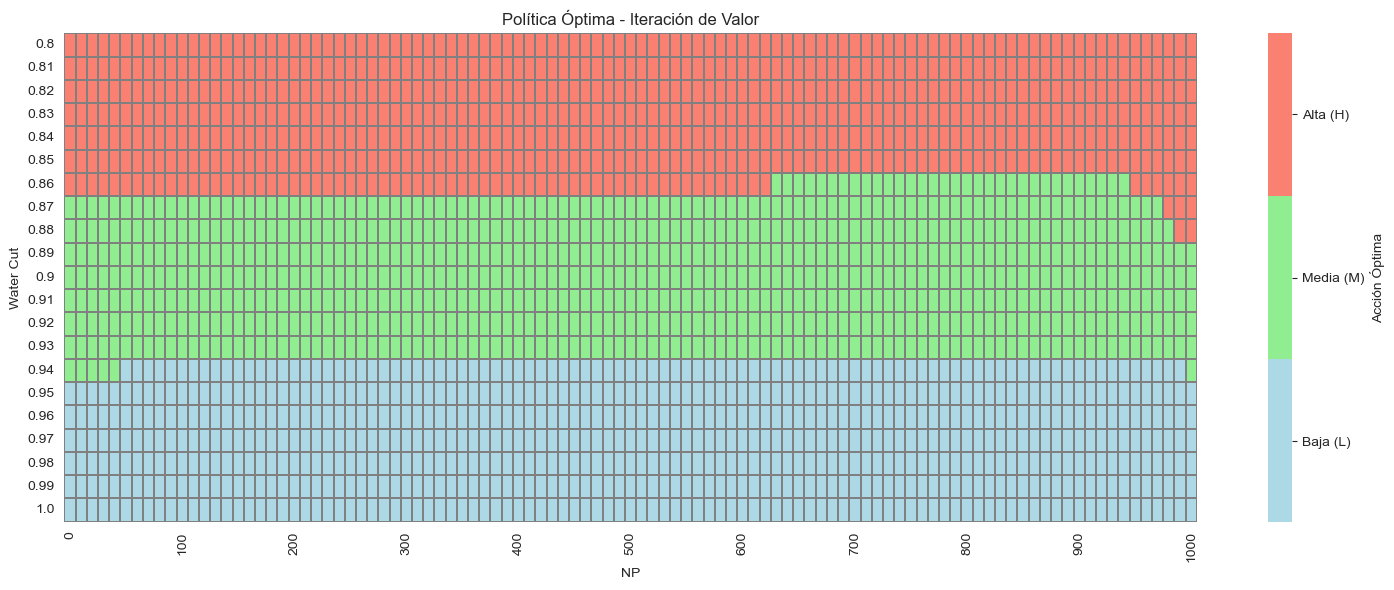

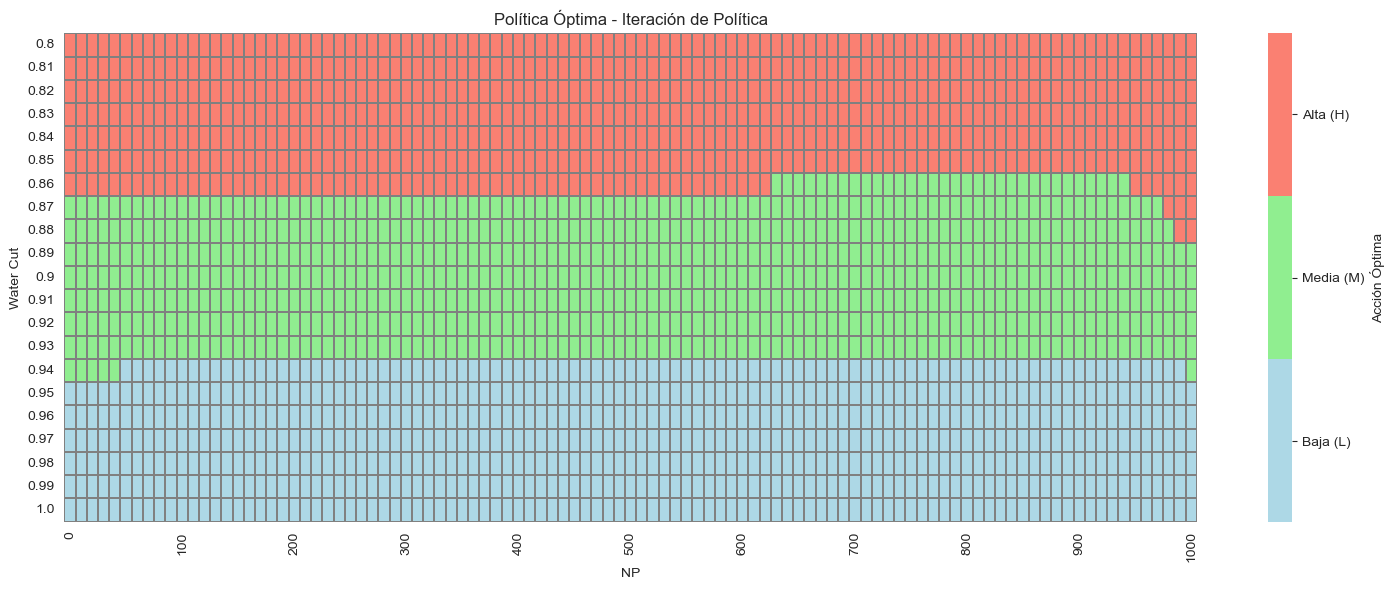

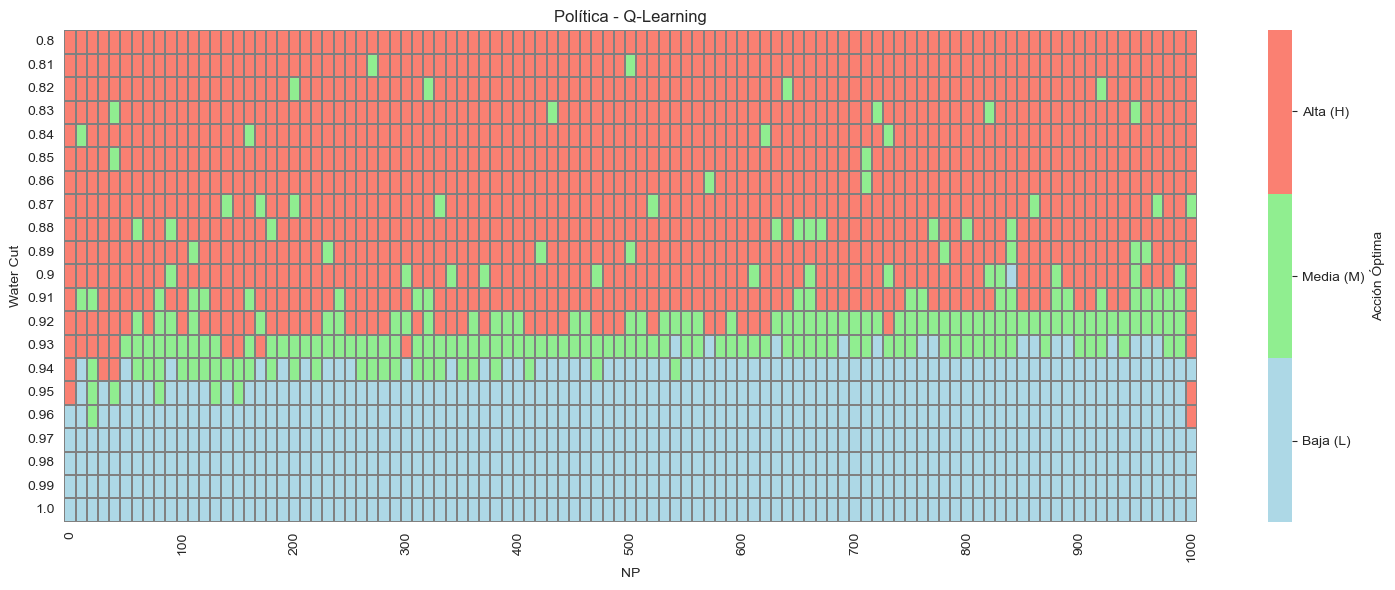

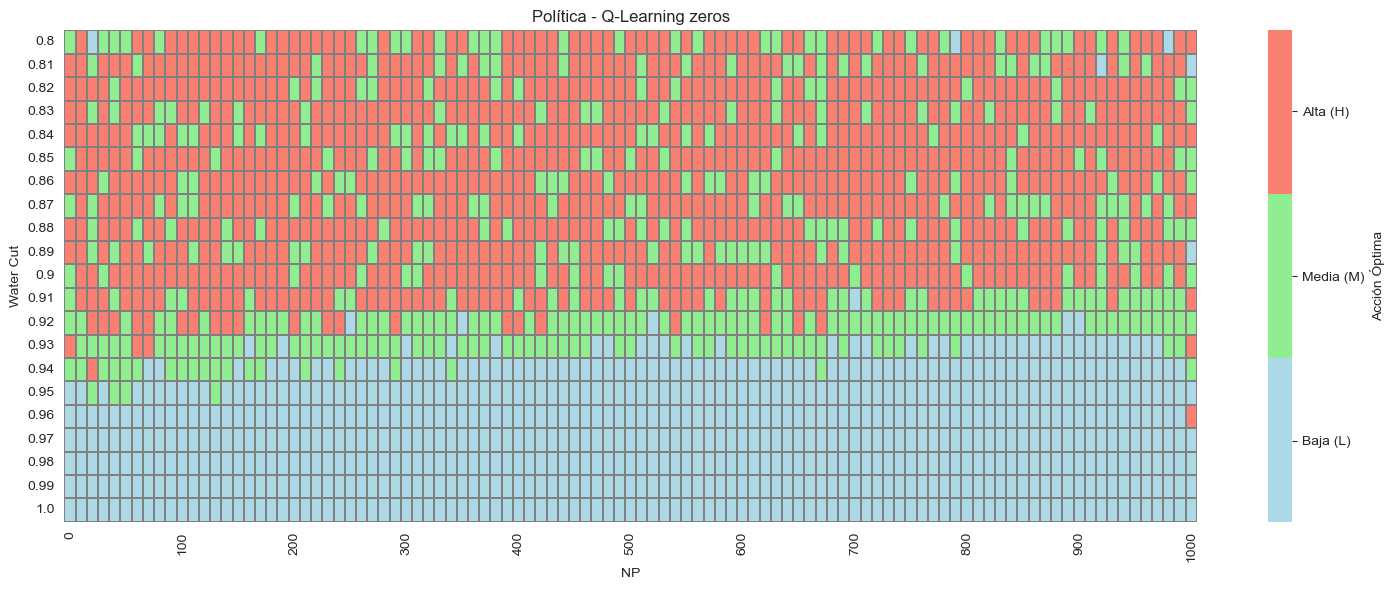

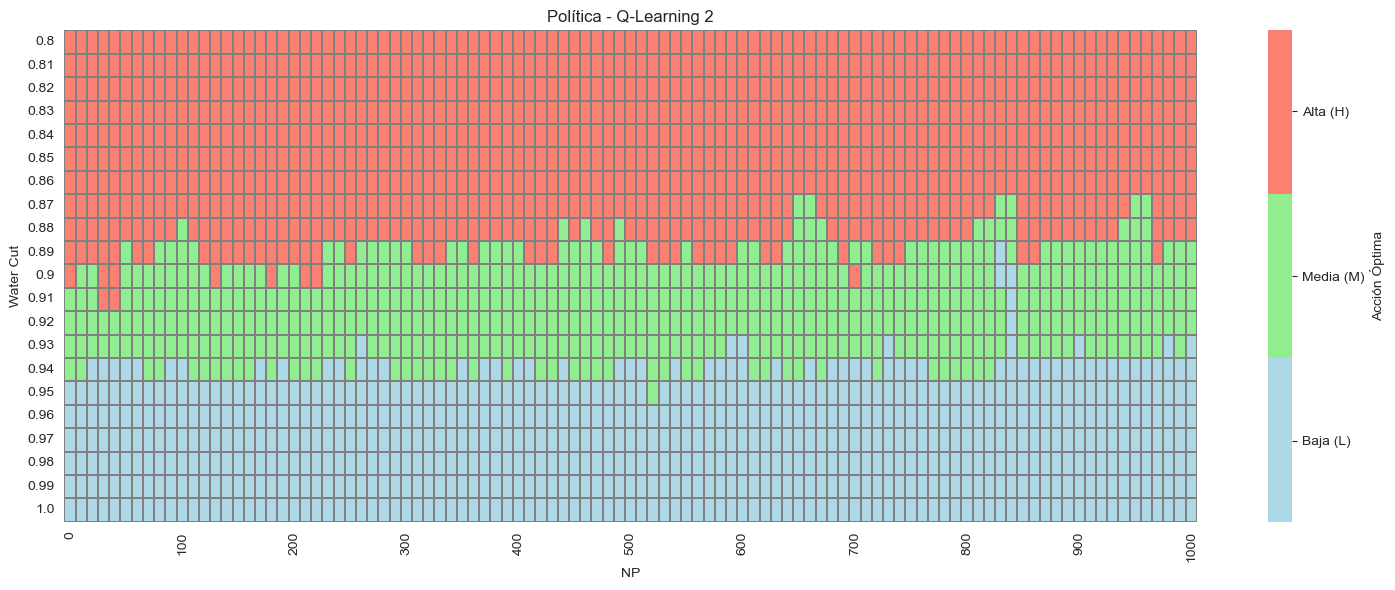

In [119]:
# Extraer valores únicos de watercut y np
wc_values = sorted(set(x[0] for x in pi_opt_valor.keys()))
np_values = sorted(set(x[1] for x in pi_opt_valor.keys()))

# Visualizar las políticas
visualizar_politica(pi_opt_valor, wc_values, np_values, "Política Óptima - Iteración de Valor")
visualizar_politica(pi_opt_politica, wc_values, np_values, "Política Óptima - Iteración de Política")
visualizar_politica(pi_opt_ql, wc_values, np_values, "Política - Q-Learning")
visualizar_politica(pi_opt_ql_zero, wc_values, np_values, "Política - Q-Learning zeros")
visualizar_politica(pi_opt_ql_2, wc_values, np_values, "Política - Q-Learning 2")

### Ajuste de hiperparámetros

Q-Learning

In [109]:
def hyper_search(epsilons, iters, pi_optima):
    times = []
    Q_values = []
    coincidencias = []

    for eps, iter in it.product(epsilons, iters):
        print(f"Epsilon: {eps}, Iteraciones: {iter}")
        start_time = time.time()
        Q, pi_q = q_learning(modelo, s=s, a=a, epsilon=eps, max_iter=iter, init='recorrido', verbose=True)
        times.append(time.time() - start_time)

        # Calcular dataframe con información para análisis
        df_q = pd.DataFrame([
              {
                  "wcut": estado[0],
                  "np": estado[1],
                  "accion_q": pi_q[estado],
                  "valor_q": max(Q[(estado, act)][1] for act in a),
                  "N_q": sum(Q[(estado, act)][0] for act in a)
              }
              for estado in s
        ])
        Q_values.append(df_q['valor_q'].max())

        # Calcular porcentaje de coincidencia con la política óptima
        coincidencia = sum(1 for estado in s if pi_q[estado] == pi_optima[estado]) / len(s) * 100
        coincidencias.append(coincidencia)

    return times, Q_values, coincidencias

In [110]:
# epsilons = [i/100 for i in range(1, 12, 5)]
epsilons = [0.01, .05, .1,.3, .5, 0.7, 0.9]
iters = [10000, 20000, 30000]
tiempo, valor_q , pct_coincidencias= hyper_search(epsilons, iters, pi_opt_valor)
print(tiempo)
print(valor_q)

Epsilon: 0.01, Iteraciones: 10000
Progreso: 50%  |  Estado-Acción recorridos: 8309394
Progreso: 90%  |  Estado-Acción recorridos: 14039402
Epsilon: 0.01, Iteraciones: 20000
Progreso: 50%  |  Estado-Acción recorridos: 15432260
Progreso: 90%  |  Estado-Acción recorridos: 26061714
Epsilon: 0.01, Iteraciones: 30000
Progreso: 50%  |  Estado-Acción recorridos: 22177835
Progreso: 90%  |  Estado-Acción recorridos: 37425265
Epsilon: 0.05, Iteraciones: 10000
Progreso: 50%  |  Estado-Acción recorridos: 7555972
Progreso: 90%  |  Estado-Acción recorridos: 12803827
Epsilon: 0.05, Iteraciones: 20000
Progreso: 50%  |  Estado-Acción recorridos: 14135467
Progreso: 90%  |  Estado-Acción recorridos: 24040470
Epsilon: 0.05, Iteraciones: 30000
Progreso: 50%  |  Estado-Acción recorridos: 20411220
Progreso: 90%  |  Estado-Acción recorridos: 34623179
Epsilon: 0.1, Iteraciones: 10000
Progreso: 50%  |  Estado-Acción recorridos: 7727625
Progreso: 90%  |  Estado-Acción recorridos: 13116126
Epsilon: 0.1, Iteracione

In [111]:
resultados = pd.DataFrame()
resultados[['epsilon', 'iteraciones']] = list(it.product(epsilons, iters))
resultados['tiempo'] = tiempo
resultados['valor_q'] = valor_q
resultados['coincidencia'] = pct_coincidencias
resultados

,epsilon,iteraciones,tiempo,valor_q,coincidencia
0,0.01,10000.0,124.791991,7.891725e+06,57.944366
1,0.01,20000.0,222.643147,8.388369e+06,60.773220
2,0.01,30000.0,325.366078,9.153794e+06,62.329090
3,0.05,10000.0,111.714146,7.671655e+06,62.470533
4,0.05,20000.0,210.772057,8.831409e+06,65.016502
5,0.05,30000.0,297.313417,9.259439e+06,66.148043
6,0.10,10000.0,110.105875,7.898479e+06,64.167845
7,0.10,20000.0,203.562342,8.971767e+06,66.525224
8,0.10,30000.0,294.485688,9.610877e+06,67.751061
9,0.30,10000.0,156.461228,7.931055e+06,66.713814


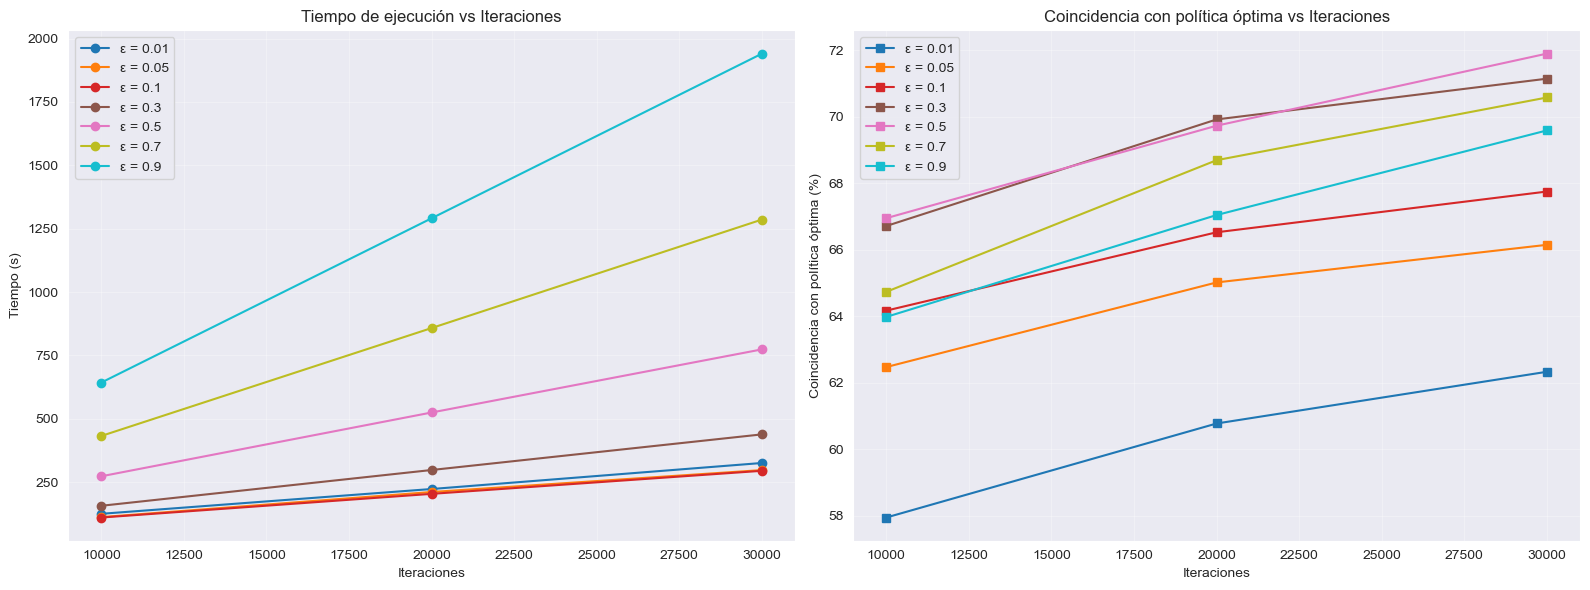

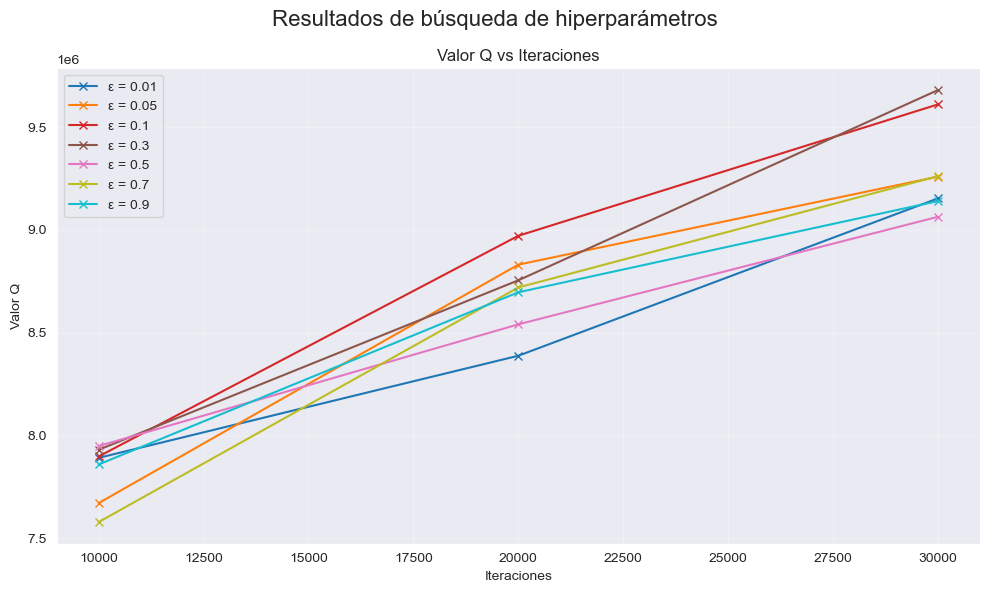

In [120]:
def plot_hyper_search(resultados):
    # Crear una figura con dos subplots lado a lado (1x2)
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Obtener valores únicos de epsilon para asignar colores
    epsilons = resultados['epsilon'].unique()
    colores = plt.cm.tab10(np.linspace(0, 1, len(epsilons)))

    # Primer gráfico: Tiempo vs Iteraciones por Epsilon
    for i, eps in enumerate(epsilons):
        datos = resultados[resultados['epsilon'] == eps]
        ax1.plot(datos['iteraciones'], datos['tiempo'],
                marker='o', color=colores[i],
                label=f'ε = {eps}')

    ax1.set_xlabel('Iteraciones')
    ax1.set_ylabel('Tiempo (s)')
    ax1.set_title('Tiempo de ejecución vs Iteraciones')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Segundo gráfico: Valor Q vs Iteraciones por Epsilon
    # Tercer gráfico: Coincidencia vs Iteraciones por Epsilon
    for i, eps in enumerate(epsilons):
        datos = resultados[resultados['epsilon'] == eps]
        ax2.plot(datos['iteraciones'], datos['coincidencia'],
                marker='s', color=colores[i],
                label=f'ε = {eps}')

    ax2.set_xlabel('Iteraciones')
    ax2.set_ylabel('Coincidencia con política óptima (%)')
    ax2.set_title('Coincidencia con política óptima vs Iteraciones')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # Crear un gráfico independiente para la coincidencia con la política óptima

    fig2, ax3 = plt.subplots(figsize=(10, 6))
    for i, eps in enumerate(epsilons):
        datos = resultados[resultados['epsilon'] == eps]
        ax3.plot(datos['iteraciones'], datos['valor_q'],
                marker='x', color=colores[i],
                label=f'ε = {eps}')

    ax3.set_xlabel('Iteraciones')
    ax3.set_ylabel('Valor Q')
    ax3.set_title('Valor Q vs Iteraciones')
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    # Ajustar layout y mostrar
    plt.suptitle('Resultados de búsqueda de hiperparámetros', fontsize=16)
    plt.tight_layout()
    plt.show()


plot_hyper_search(resultados)

### Q learning vs Max_Iter

In [102]:
def q_learning_acumulativo(modelo, s, a, epsilon=1e-4, max_iter=100, init='zeros', verbose=False, Q_init=None):
    """
    Q-learning con opción de acumulación.

    Args:
        modelo: instancia de WaterIny
        s: lista de estados
        a: lista de acciones ['L', 'M', 'H']a
        epsilon: probabilidad de exploración
        max_iter: cantidad de episodios
        init: 'zeros' o 'recorrido'
        verbose: muestra progreso
        Q_init: diccionario Q ya inicializado para continuar entrenamiento

    Returns:
        Q: diccionario con valores Q[(estado, accion)] = [n_visitas, valor]
        pi_q: política derivada greedy sobre Q
    """
    random.seed(42)
    Q = Q_init or {key: [0, 0] for key in it.product(s, a)}

    if init == 'recorrido' and Q_init is None:
        for est, acc in it.product(s, a):
            recompensa, siguiente_estado = modelo.transition_sample(est, acc)
            max_q_siguiente = max(Q[(siguiente_estado, act)][1] for act in a)
            Q[(est, acc)][0] += 1
            Q[(est, acc)][1] += (recompensa + max_q_siguiente - Q[(est, acc)][1]) / Q[(est, acc)][0]

    for episodio in range(max_iter):
        estado = random.choice(s)
        if episodio in [max_iter // 2, max_iter * 9 // 10] and verbose:
            print(f"Progreso: {episodio / max_iter:.0%}")

        while True:
            if random.random() < epsilon:
                accion = random.choice(a)
            else:
                accion = max(a, key=lambda act: Q[(estado, act)][1])

            recompensa, siguiente_estado = modelo.transition_sample(estado, accion)
            max_q_siguiente = max(Q[(siguiente_estado, act)][1] for act in a)

            Q[(estado, accion)][0] += 1
            Q[(estado, accion)][1] += (recompensa + max_q_siguiente - Q[(estado, accion)][1]) / Q[(estado, accion)][0]

            if siguiente_estado[1] >= modelo._np_max:
                break

            estado = siguiente_estado

    pi_q = {estado: max(a, key=lambda act: Q[(estado, act)][1]) for estado in s}
    return Q, pi_q

In [105]:
def evaluar_q_learning_acumulativo(modelo, s, a, pi_opt, max_iters, wc_values, np_values,epsilon=0.05, init='recorrido'):
    """
    Ejecuta Q-learning acumulativo (conserva Q entre pasos) para distintos valores de iteraciones.

    Args:
        modelo: instancia del modelo (WaterIny)
        s: lista de estados
        a: lista de acciones ['L', 'M', 'H']
        pi_opt: política óptima para comparar
        max_iters: lista creciente de iteraciones acumuladas (ej. [30000, 40000, ..., 100000])
        epsilon: parámetro de exploración
        init: 'zeros' o 'recorrido'

    Returns:
        resultados: dict con claves Q_<iter>, pi_q_<iter>
        df_historial: DataFrame con % coincidencia y valor Q promedio por iteración
    """
    resultados = {}
    historial = []

    Q_acumulado = None
    total_iteraciones = 0

    for max_iter in max_iters:
        pasos_nuevos = max_iter - total_iteraciones
        print(f"Ejecutando Q-Learning hasta {max_iter} iteraciones (sumando {pasos_nuevos})...")

        Q_acumulado, pi_q_actual = q_learning_acumulativo(
            modelo, s, a,
            epsilon=epsilon,
            max_iter=pasos_nuevos,
            init=init if Q_acumulado is None else 'zeros',
            Q_init=Q_acumulado
        )

        resultados[f"Q_{max_iter}"] = Q_acumulado
        resultados[f"pi_q_{max_iter}"] = pi_q_actual

        visualizar_politica(
            pi_q_actual,
            wc_values,
            np_values,
            titulo=f"Política Q-Learning acumulado - {max_iter} iteraciones"
        )

        aciertos = sum(pi_q_actual[estado] == pi_opt[estado] for estado in s)
        porcentaje = aciertos / len(s) * 100

        print(f"Iteraciones: {max_iter}, Coincidencia con política óptima: {porcentaje:.2f}%")

        promedio_q = sum(max(Q_acumulado[(estado, act)][1] for act in a) for estado in s) / len(s)

        historial.append({
            'init': init,
            'iteraciones': max_iter,
            'coincidencia_%': porcentaje,
            'valor_Q_promedio': promedio_q
        })

        total_iteraciones = max_iter

    df_historial = pd.DataFrame(historial)
    return resultados, df_historial

Ejecutando Q-Learning hasta 30000 iteraciones (sumando 30000)...


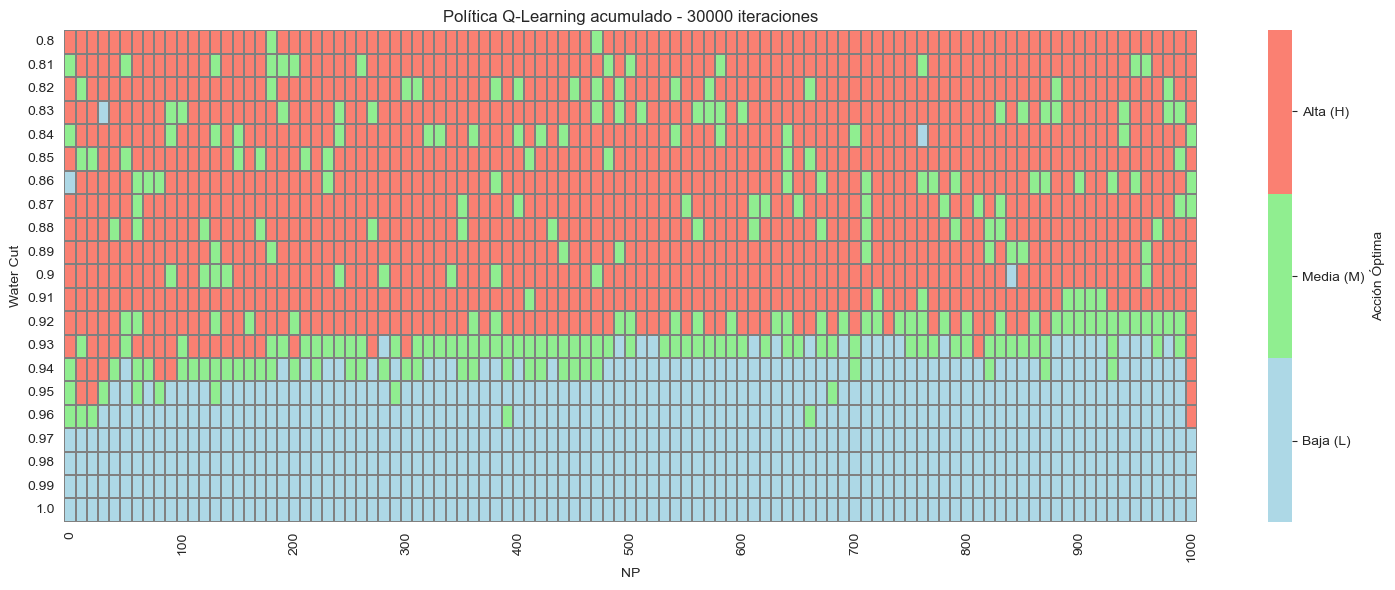

Iteraciones: 30000, Coincidencia con política óptima: 66.15%
Ejecutando Q-Learning hasta 40000 iteraciones (sumando 10000)...


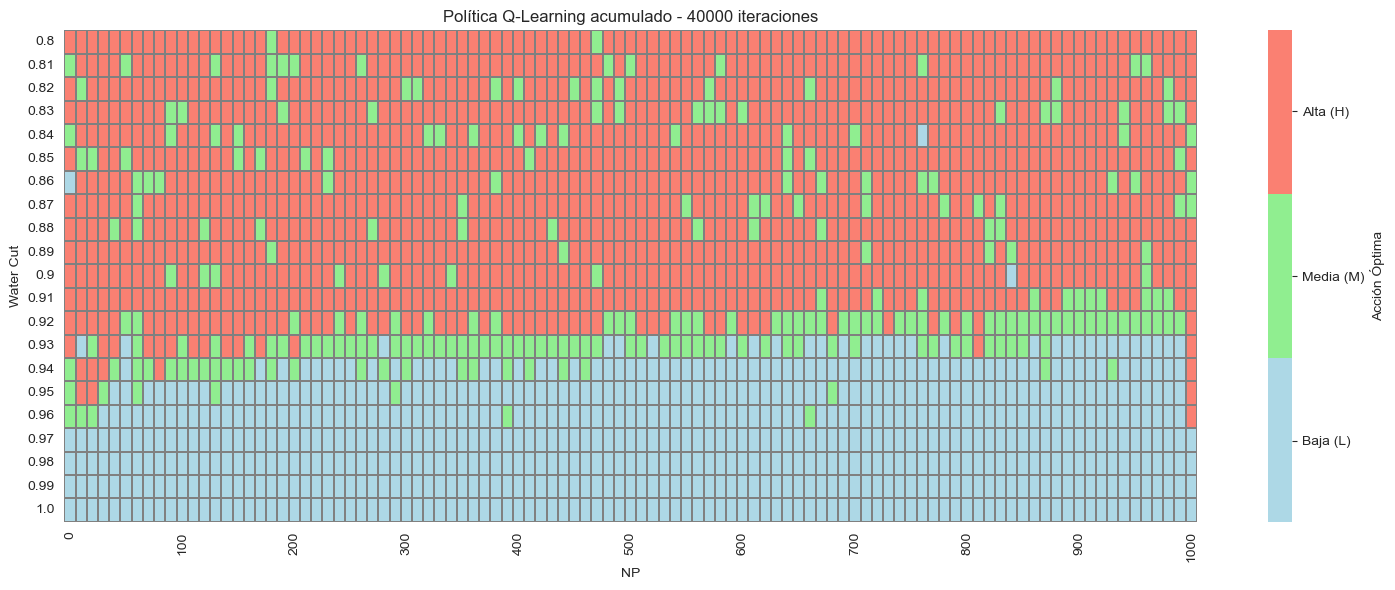

Iteraciones: 40000, Coincidencia con política óptima: 66.95%
Ejecutando Q-Learning hasta 50000 iteraciones (sumando 10000)...


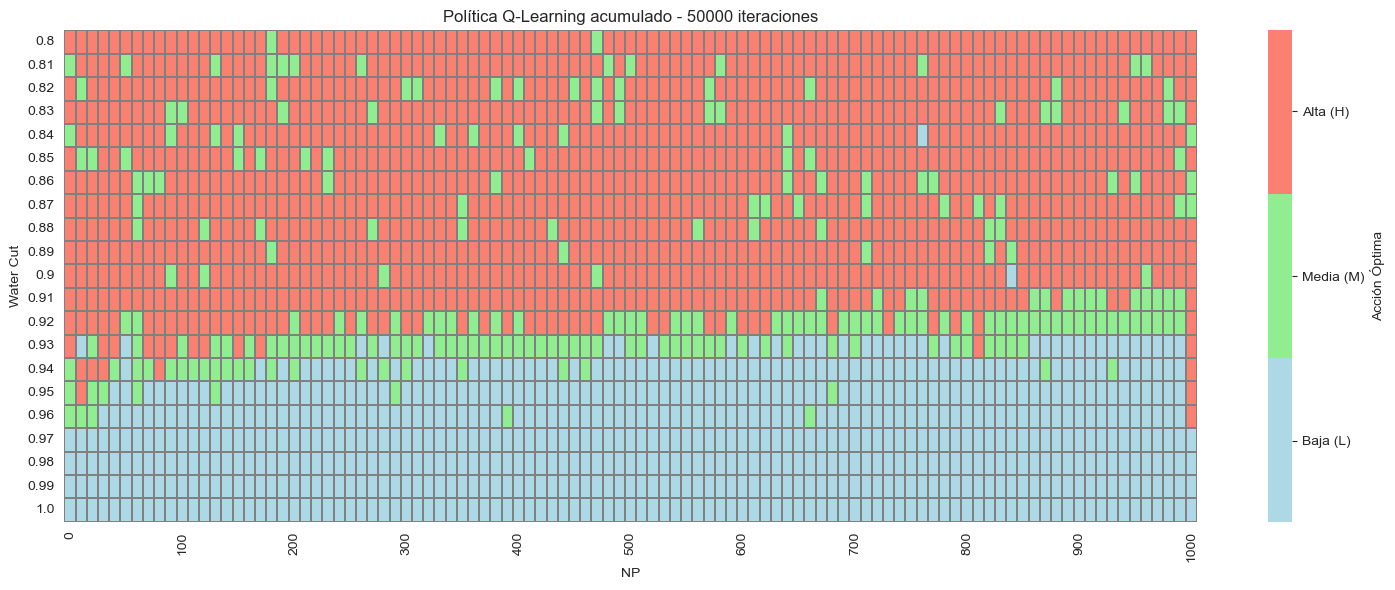

Iteraciones: 50000, Coincidencia con política óptima: 67.42%
Ejecutando Q-Learning hasta 60000 iteraciones (sumando 10000)...


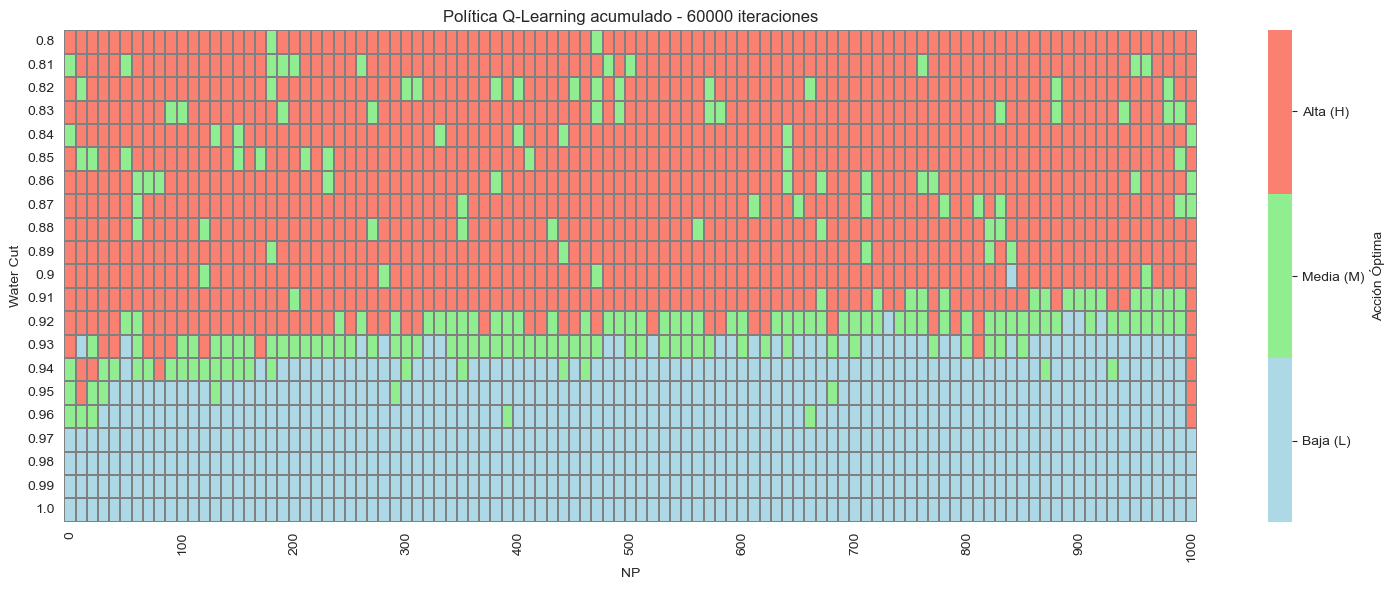

Iteraciones: 60000, Coincidencia con política óptima: 67.85%
Ejecutando Q-Learning hasta 70000 iteraciones (sumando 10000)...


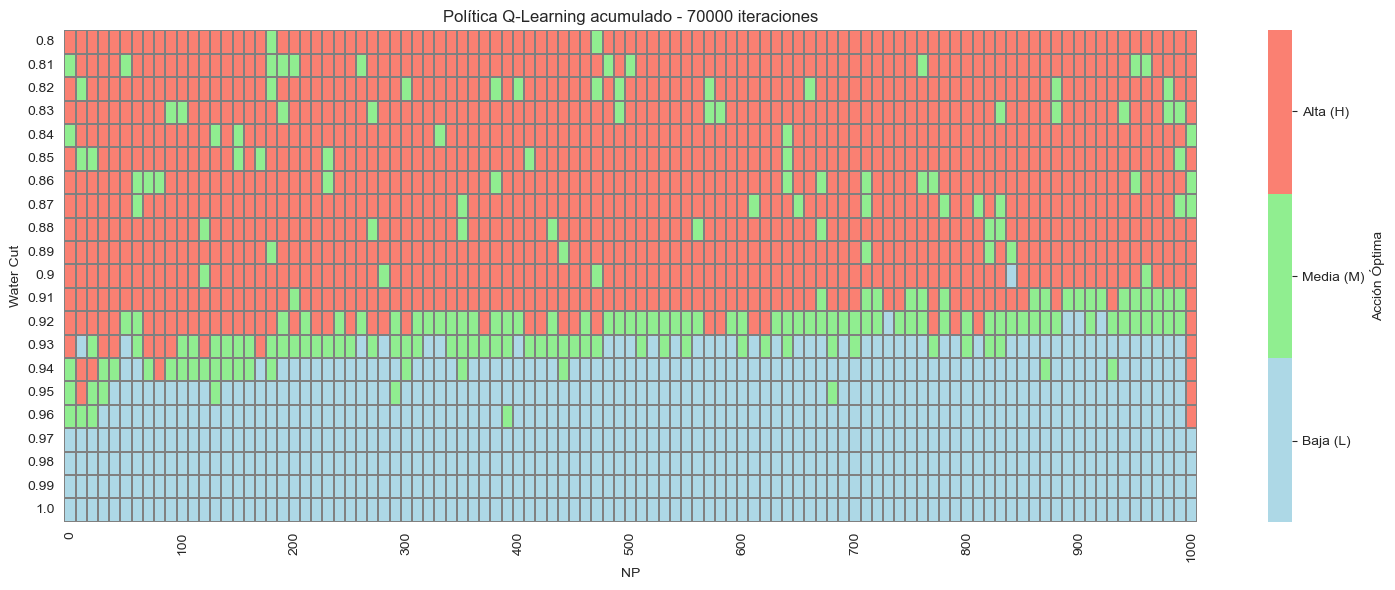

Iteraciones: 70000, Coincidencia con política óptima: 68.32%
Ejecutando Q-Learning hasta 80000 iteraciones (sumando 10000)...


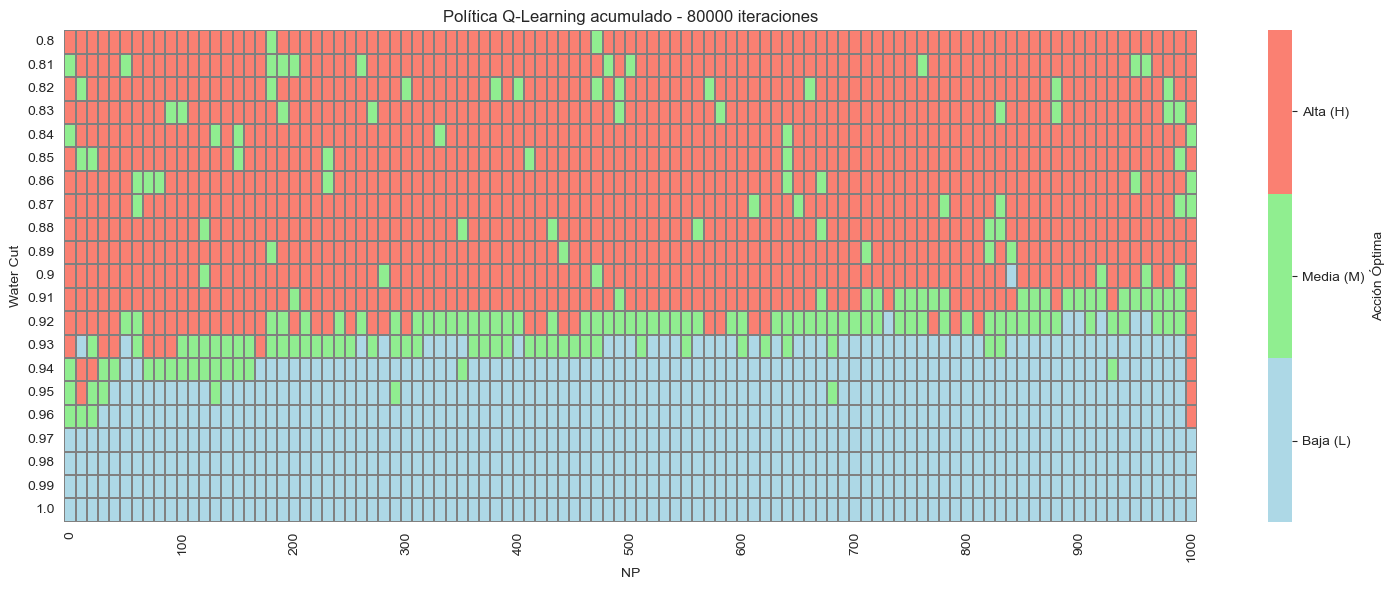

Iteraciones: 80000, Coincidencia con política óptima: 68.51%
Ejecutando Q-Learning hasta 90000 iteraciones (sumando 10000)...


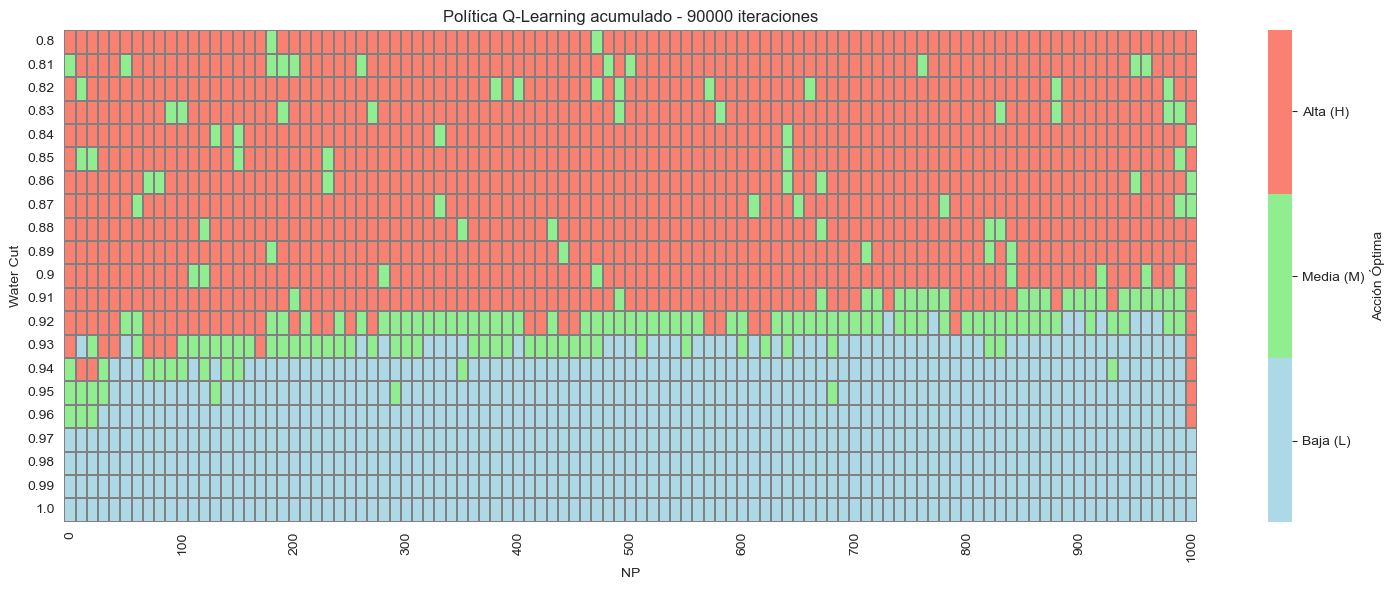

Iteraciones: 90000, Coincidencia con política óptima: 68.98%
Ejecutando Q-Learning hasta 100000 iteraciones (sumando 10000)...


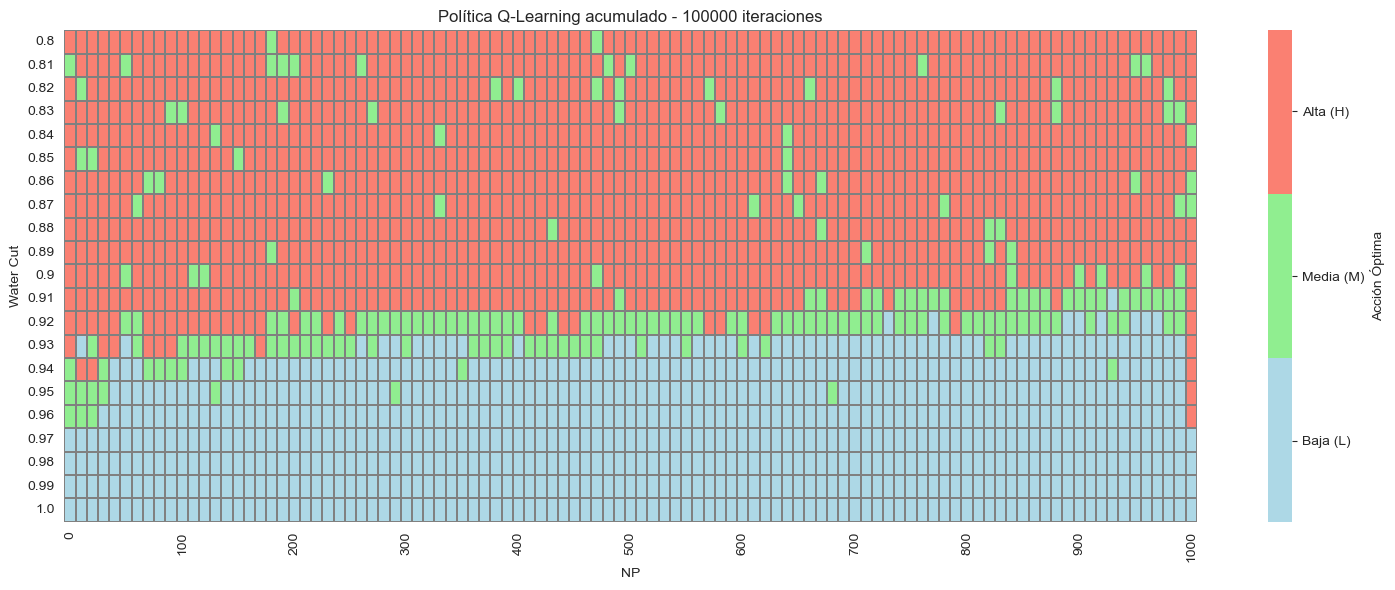

Iteraciones: 100000, Coincidencia con política óptima: 69.07%


In [106]:
max_iters = range(30000, 110000, 10000)

resultados_q, df_q_hist = evaluar_q_learning_acumulativo(
    modelo=modelo,
    s=s,
    a=a,
    pi_opt=pi_opt_valor,
    max_iters=max_iters,
    np_values=np_values,
    wc_values=wc_values,
    epsilon=0.05,
    init='recorrido'  # o 'zeros'
)

Ejecutando Q-Learning hasta 30000 iteraciones (sumando 30000)...


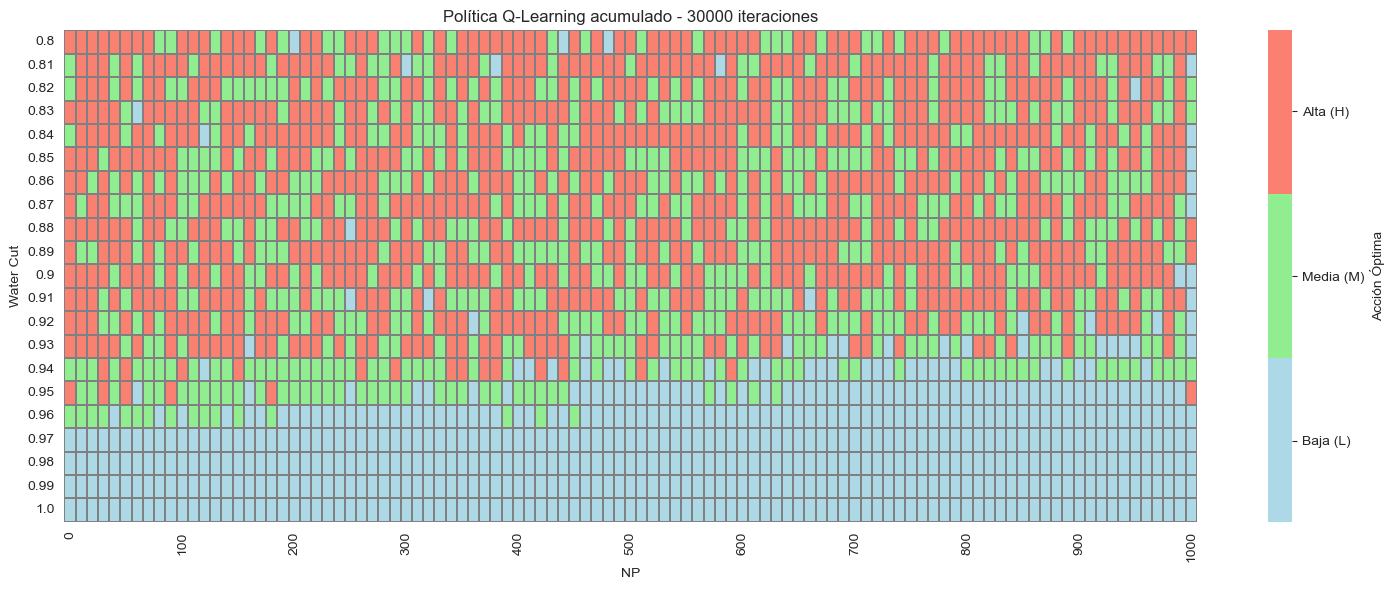

Iteraciones: 30000, Coincidencia con política óptima: 61.01%
Ejecutando Q-Learning hasta 40000 iteraciones (sumando 10000)...


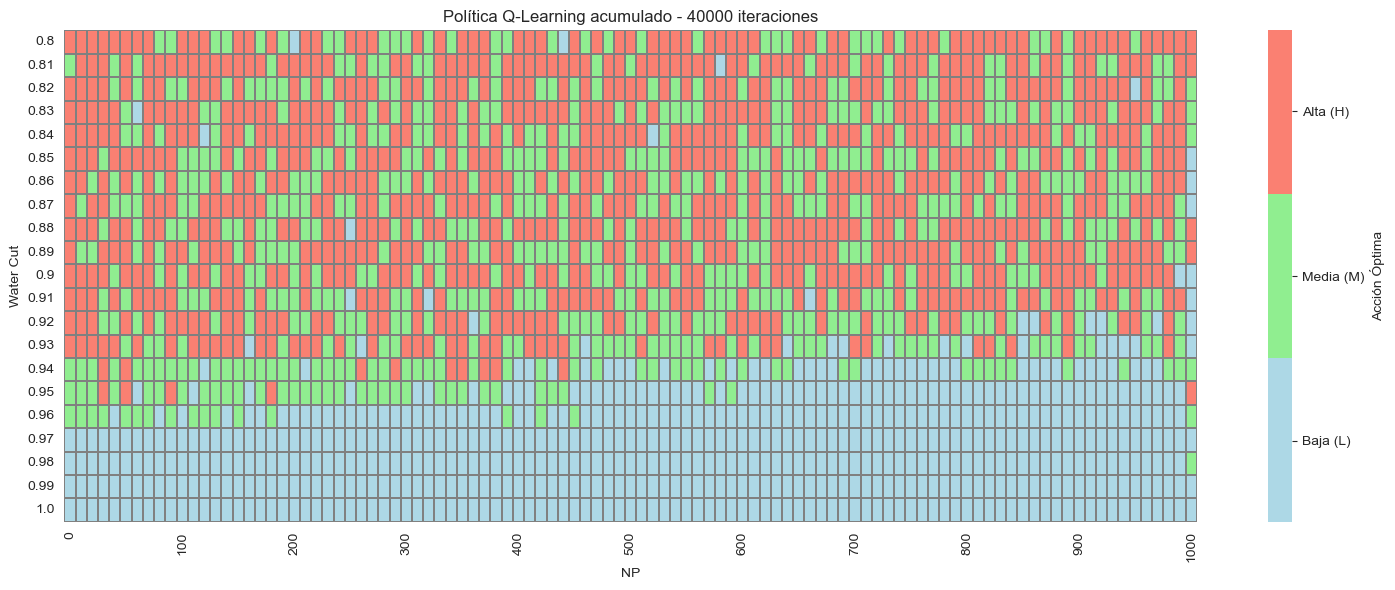

Iteraciones: 40000, Coincidencia con política óptima: 61.95%
Ejecutando Q-Learning hasta 50000 iteraciones (sumando 10000)...


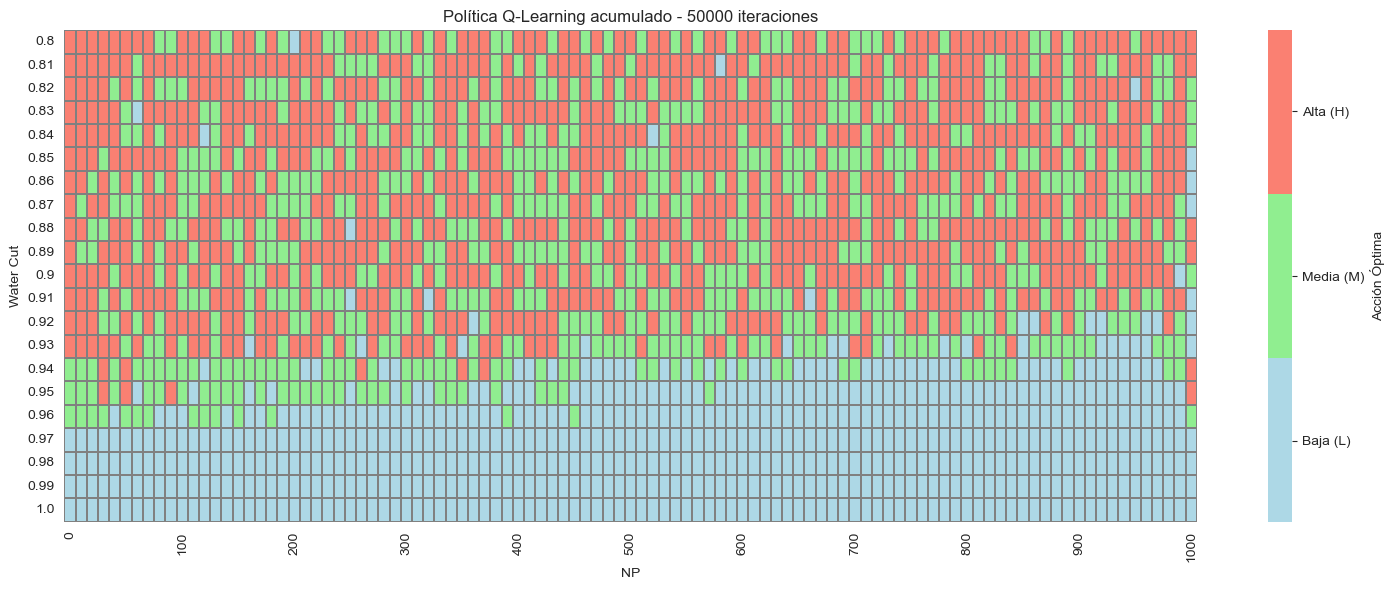

Iteraciones: 50000, Coincidencia con política óptima: 62.89%
Ejecutando Q-Learning hasta 60000 iteraciones (sumando 10000)...


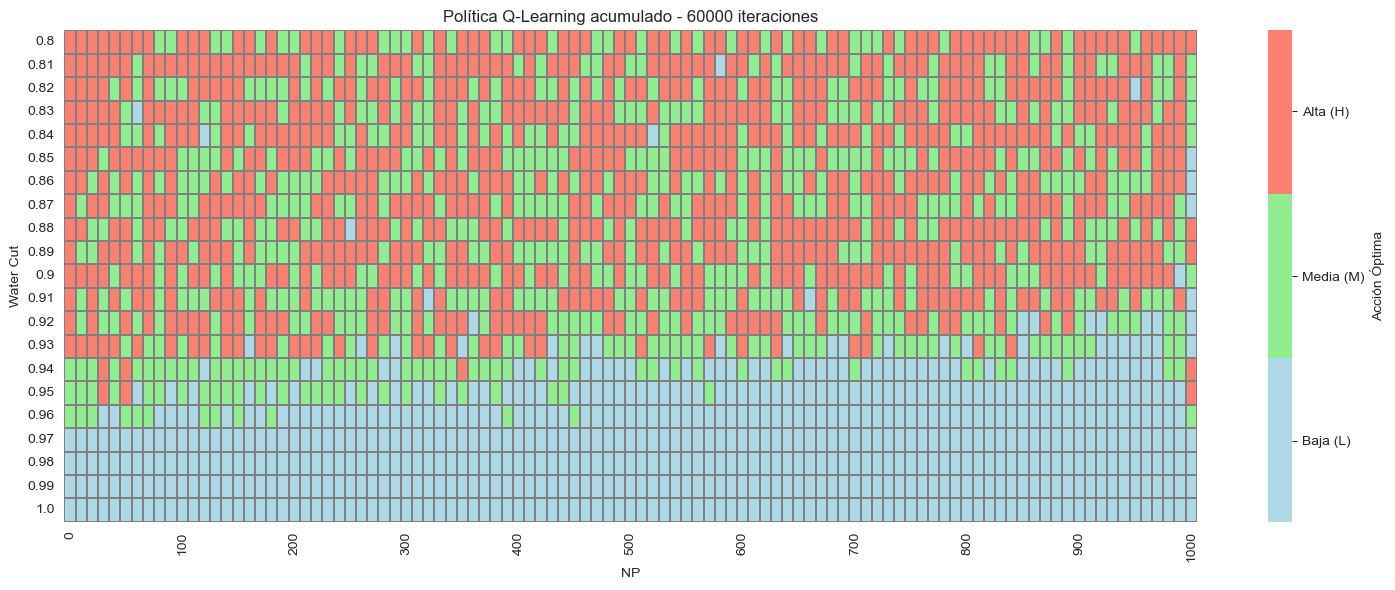

Iteraciones: 60000, Coincidencia con política óptima: 63.74%
Ejecutando Q-Learning hasta 70000 iteraciones (sumando 10000)...


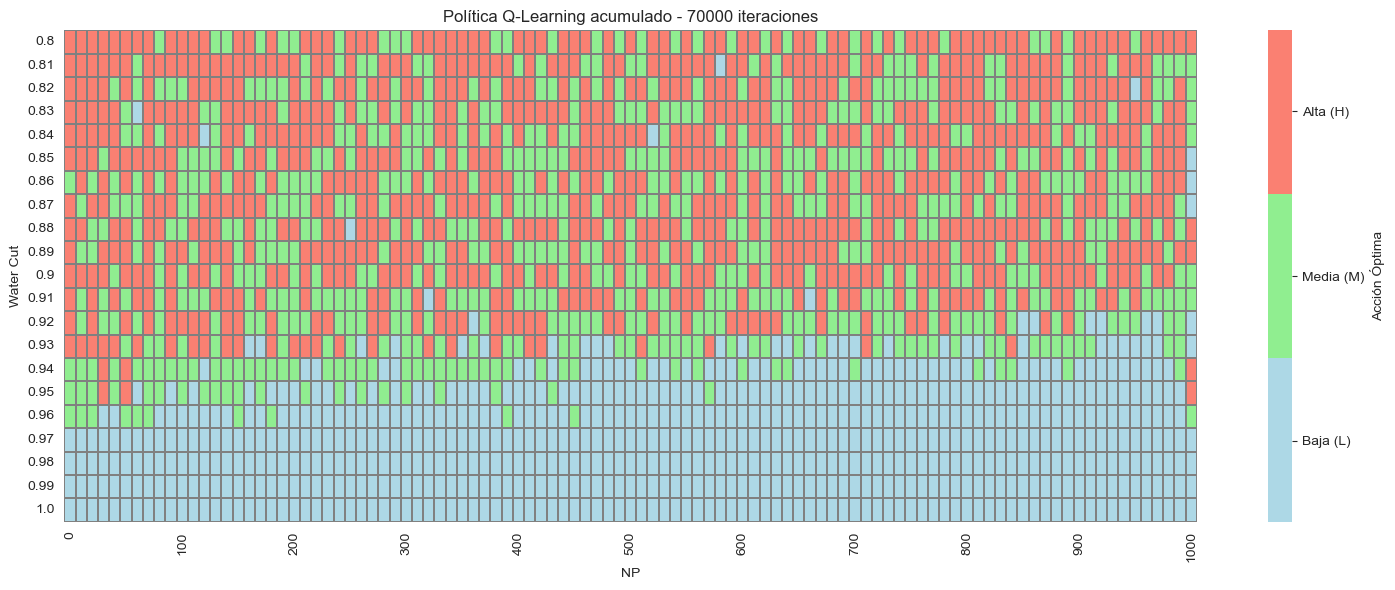

Iteraciones: 70000, Coincidencia con política óptima: 64.45%
Ejecutando Q-Learning hasta 80000 iteraciones (sumando 10000)...


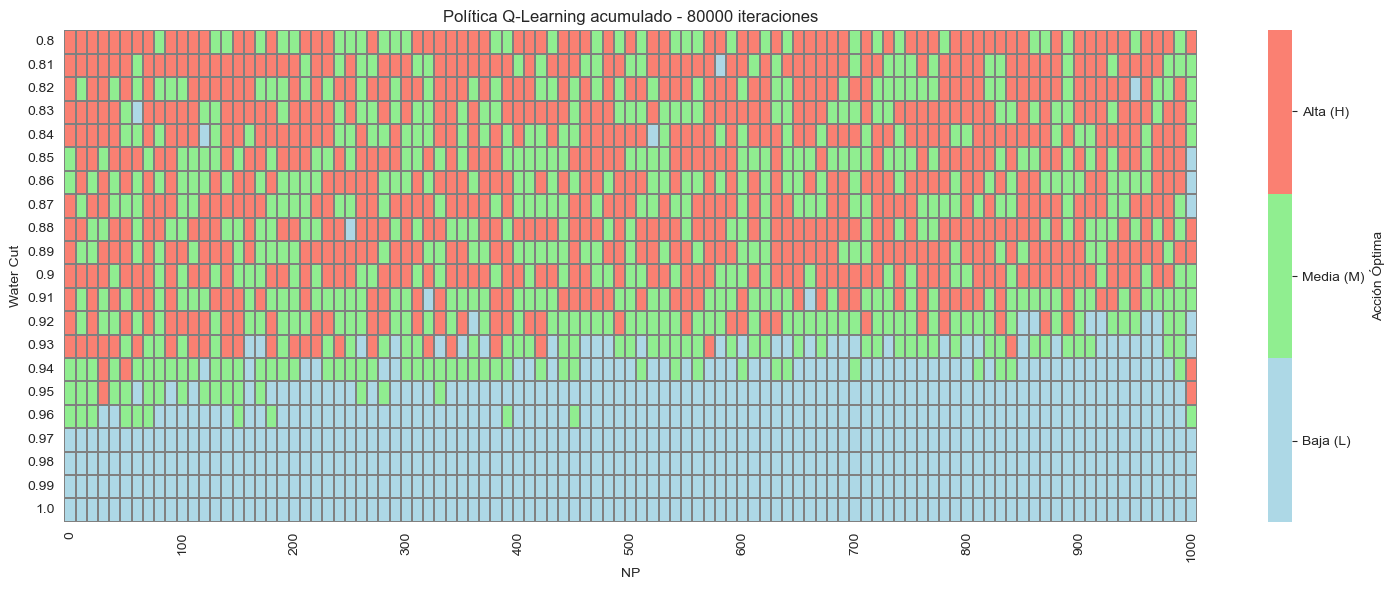

Iteraciones: 80000, Coincidencia con política óptima: 65.02%
Ejecutando Q-Learning hasta 90000 iteraciones (sumando 10000)...


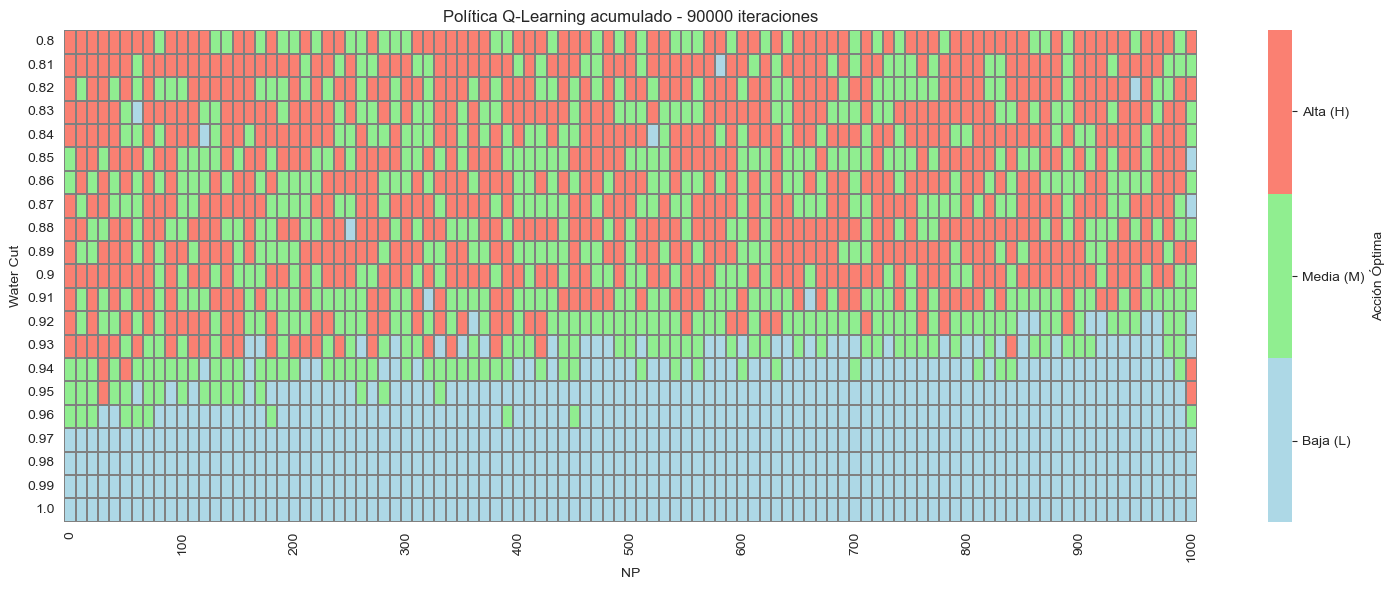

Iteraciones: 90000, Coincidencia con política óptima: 65.21%
Ejecutando Q-Learning hasta 100000 iteraciones (sumando 10000)...


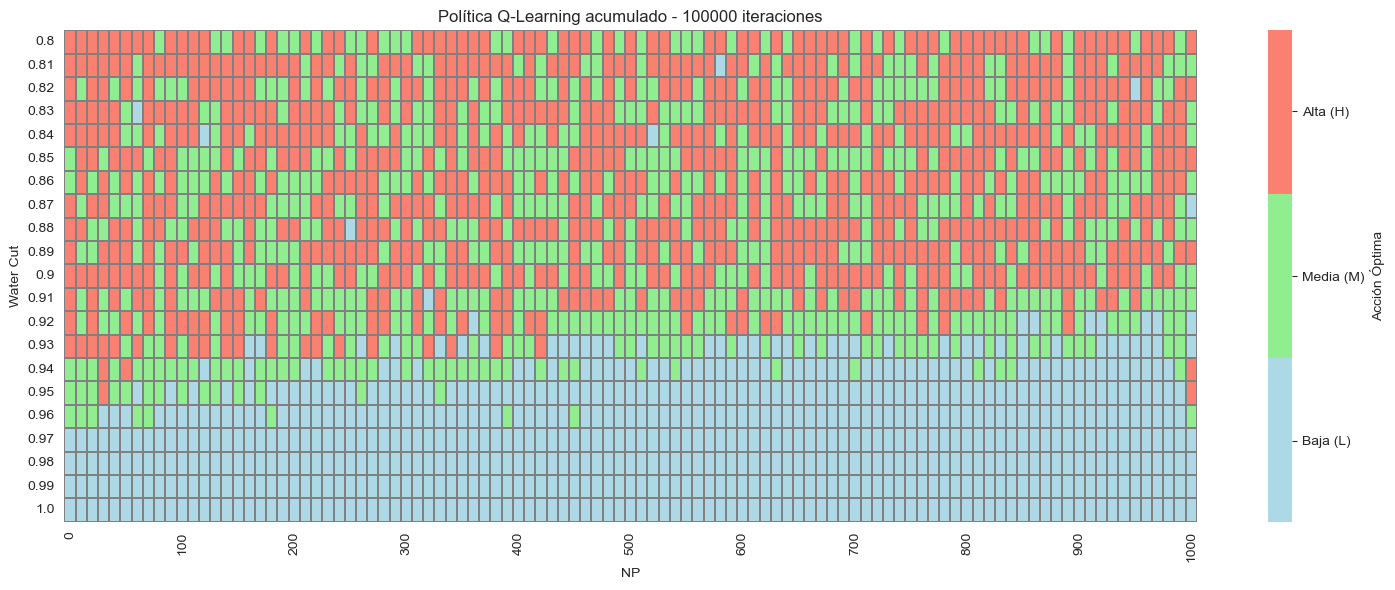

Iteraciones: 100000, Coincidencia con política óptima: 65.44%


In [107]:
max_iters = range(30000, 110000, 10000)

resultados_q_zeros, df_q_hist_zeros = evaluar_q_learning_acumulativo(
    modelo=modelo,
    s=s,
    a=a,
    pi_opt=pi_opt_valor,
    max_iters=max_iters,
    np_values=np_values,
    wc_values=wc_values,
    epsilon=0.05,
    init='zeros'  # o 'zeros'
)

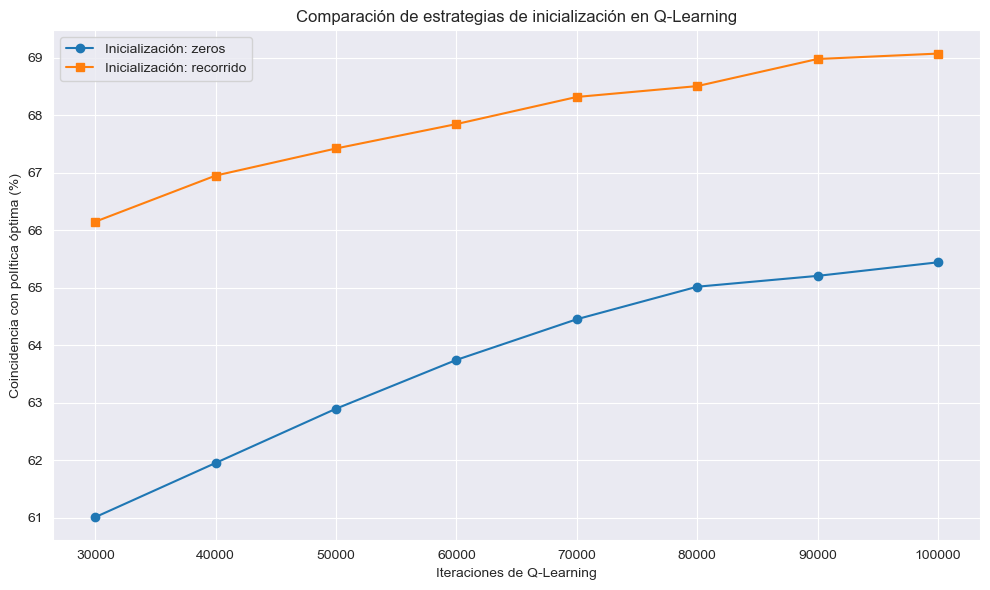

In [108]:
plt.figure(figsize=(10, 6))

# Línea para init='zeros'
plt.plot(
    df_q_hist_zeros['iteraciones'],
    df_q_hist_zeros['coincidencia_%'],
    marker='o',
    label='Inicialización: zeros'
)

# Línea para init='recorrido'
plt.plot(
    df_q_hist['iteraciones'],
    df_q_hist['coincidencia_%'],
    marker='s',
    label='Inicialización: recorrido'
)

plt.xlabel("Iteraciones de Q-Learning")
plt.ylabel("Coincidencia con política óptima (%)")
plt.title("Comparación de estrategias de inicialización en Q-Learning")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Tiempo finito

In [88]:
def iteracion_valor_finito(modelo, horizonte=120):
    # Inicializar matrices para cada paso de tiempo
    V = [{} for _ in range(horizonte + 1)]
    pi = [{} for _ in range(horizonte)]

    # Valor terminal (t=horizonte) es cero para todos los estados
    for x in modelo._s:
        V[horizonte][x] = 0

    # Programación dinámica hacia atrás
    for t in range(horizonte - 1, -1, -1):
        for x in modelo._s:
            valores_acciones = {}
            for a in modelo._a:
                # Calcular valor esperado
                prob_wc_next, prob_np_next = modelo.transicion(x, a)
                v_esperado = 0

                for i, delta_wc in enumerate([-0.01, 0, 0.01]):
                    wc_prime = round(x[0] + delta_wc, 2)
                    if wc_prime not in modelo._wcs:
                        continue
                    for j, delta_np in enumerate([0, modelo._np_res]):
                        np_prime = x[1] + delta_np
                        if np_prime > modelo._np_max:
                            continue
                        y = (wc_prime, np_prime)
                        p = prob_wc_next[i] * prob_np_next[j]
                        v_esperado += p * V[t+1].get(y, 0)

                valores_acciones[a] = modelo.reward(x, a) + modelo._alpha * v_esperado

            # Actualizar función valor y política
            best_action = max(valores_acciones, key=valores_acciones.get)
            V[t][x] = valores_acciones[best_action]
            pi[t][x] = best_action

    return V, pi

def visualizar_politica_tiempo(modelo, pi, tiempo, horizonte=120):
    """
    Visualiza la política óptima en un tiempo específico
    """
    # Extraer valores únicos de watercut y np
    wc_values = sorted(set(x[0] for x in pi[tiempo].keys()))
    np_values = sorted(set(x[1] for x in pi[tiempo].keys()))

    # Crear matriz para el mapa de calor
    policy_matrix = np.zeros((len(wc_values), len(np_values)), dtype=int)
    action_map = {'L': 0, 'M': 1, 'H': 2}

    # Llenar la matriz con las acciones codificadas
    for i, wc in enumerate(wc_values):
        for j, np_val in enumerate(np_values):
            if (wc, np_val) in pi[tiempo]:
                policy_matrix[i, j] = action_map[pi[tiempo][(wc, np_val)]]

    # Crear el mapa de calor
    plt.figure(figsize=(15, 6))
    ax = sns.heatmap(policy_matrix, cmap=['lightblue', 'lightgreen', 'salmon'],
                    cbar_kws={'ticks': [0.33, 1, 1.67], 'label': 'Acción Óptima'},
                    linewidths=0.1, linecolor='gray')

    # Configurar etiquetas
    ax.set_yticks(np.arange(len(wc_values)) + 0.5)
    ax.set_yticklabels(wc_values)
    ax.set_xticks(np.arange(0, len(np_values), 10) + 0.5)
    ax.set_xticklabels(np_values[::10])

    # Personalizar el mapa de calor
    tiempo_restante = horizonte - tiempo
    plt.title(f'Política Óptima (Trimestre {tiempo}, {tiempo_restante} trimestres restantes)')
    plt.xlabel('NP')
    plt.ylabel('Water Cut')
    colorbar = ax.collections[0].colorbar
    colorbar.set_ticklabels(['Baja (L)', 'Media (M)', 'Alta (H)'])

    plt.tight_layout()
    plt.show()

In [89]:
def comparar_politicas_tiempos(modelo, pi, tiempos, horizonte=120):
        """
        Compara las políticas óptimas en diferentes momentos del horizonte
        organizadas en una cuadrícula 2x2
        """
        if len(tiempos) != 4:
            raise ValueError("Esta función está optimizada para exactamente 4 tiempos en formato 2x2")

        # Crear grid 2x2
        fig, axes = plt.subplots(2, 2, figsize=(10, 10))
        axes = axes.flatten()  # Convertir a un array 1D para indexar fácilmente

        # Extraer valores únicos de watercut y np
        wc_values = sorted(set(x[0] for x in pi[0].keys()))
        np_values = sorted(set(x[1] for x in pi[0].keys()))

        action_map = {'L': 0, 'M': 1, 'H': 2}

        for idx, tiempo in enumerate(tiempos):
            # Crear matriz para el mapa de calor
            policy_matrix = np.zeros((len(wc_values), len(np_values)), dtype=int)

            # Llenar la matriz con las acciones codificadas
            for i, wc in enumerate(wc_values):
                for j, np_val in enumerate(np_values):
                    if (wc, np_val) in pi[tiempo]:
                        policy_matrix[i, j] = action_map[pi[tiempo][(wc, np_val)]]

            # Crear el mapa de calor
            ax = axes[idx]
            sns.heatmap(policy_matrix, cmap=['lightblue', 'lightgreen', 'salmon'],
                       cbar_kws={'ticks': [0.33, 1, 1.67], 'label': 'Acción'},
                       linewidths=0.1, linecolor='gray', ax=ax)

            # Configurar etiquetas
            ax.set_yticks(np.arange(len(wc_values)) + 0.5)
            # Solo mostrar etiquetas y en la columna izquierda (índices 0 y 2)
            ax.set_yticklabels(wc_values) if idx % 2 == 0 else ax.set_yticklabels([])
            ax.set_xticks(np.arange(0, len(np_values), 20) + 0.5)
            ax.set_xticklabels(np_values[::20])
            ax.tick_params(axis='y', rotation=0)

            # Personalizar el mapa de calor
            tiempo_restante = horizonte - tiempo
            ax.set_title(f'Trimestre {tiempo}\n({tiempo_restante} restantes)')
            ax.set_xlabel('NP')
            if idx % 2 == 0:  # Solo para la columna izquierda
                ax.set_ylabel('Water Cut')
            colorbar = ax.collections[0].colorbar
            colorbar.set_ticklabels(['Baja (L)', 'Media (M)', 'Alta (H)'])

        plt.tight_layout()
        plt.suptitle('Comparación de Políticas Óptimas', y=1.02)
        plt.show()

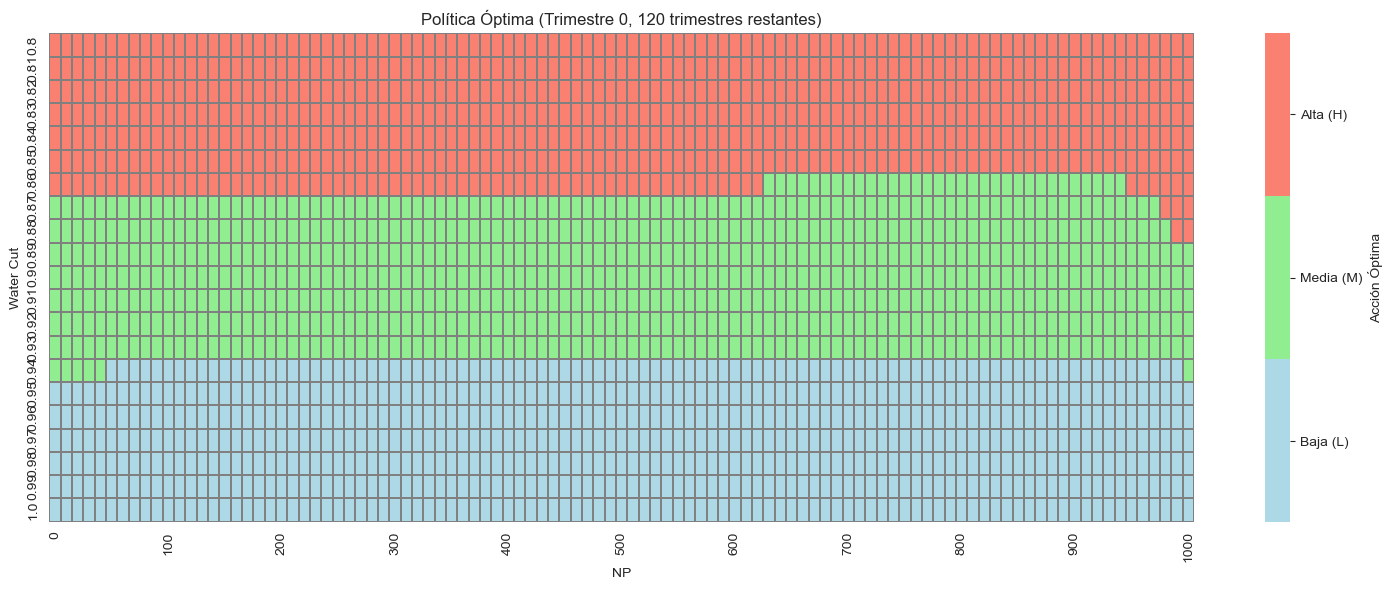

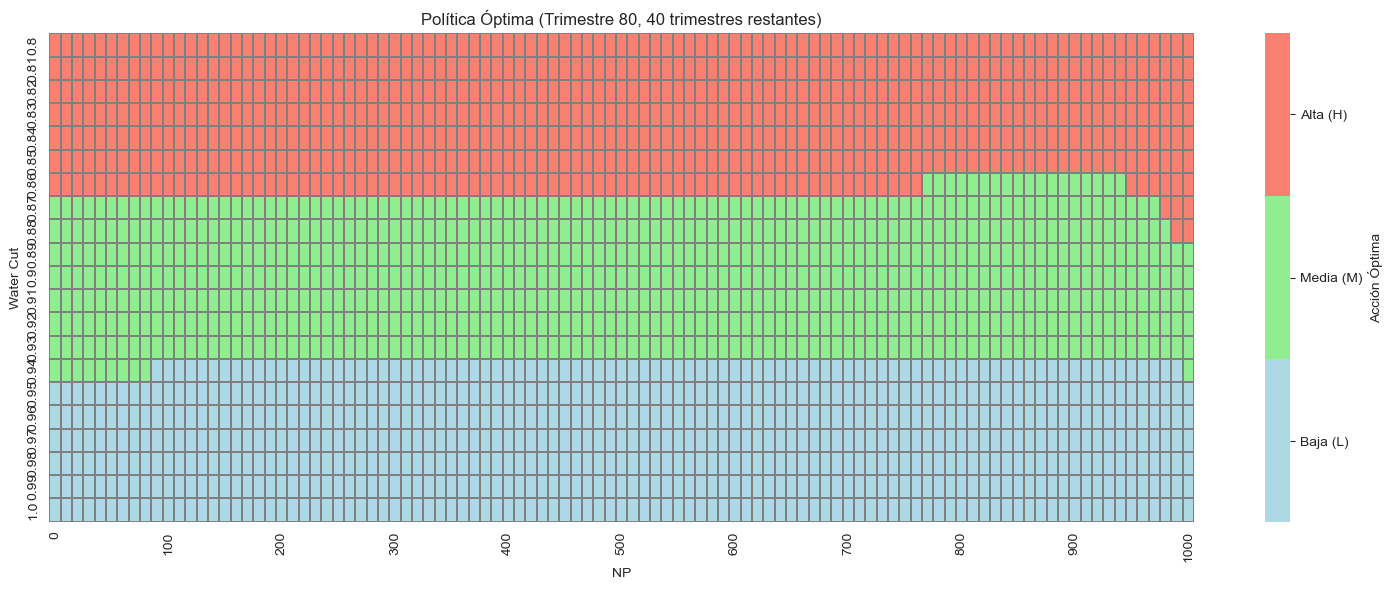

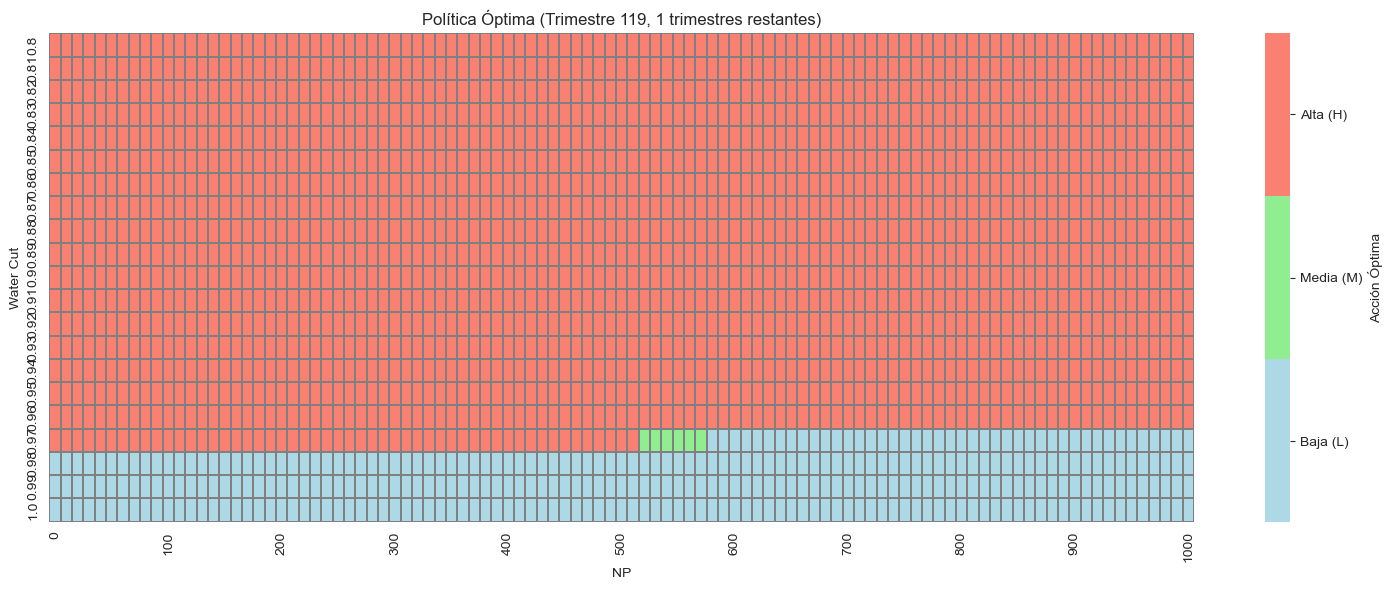

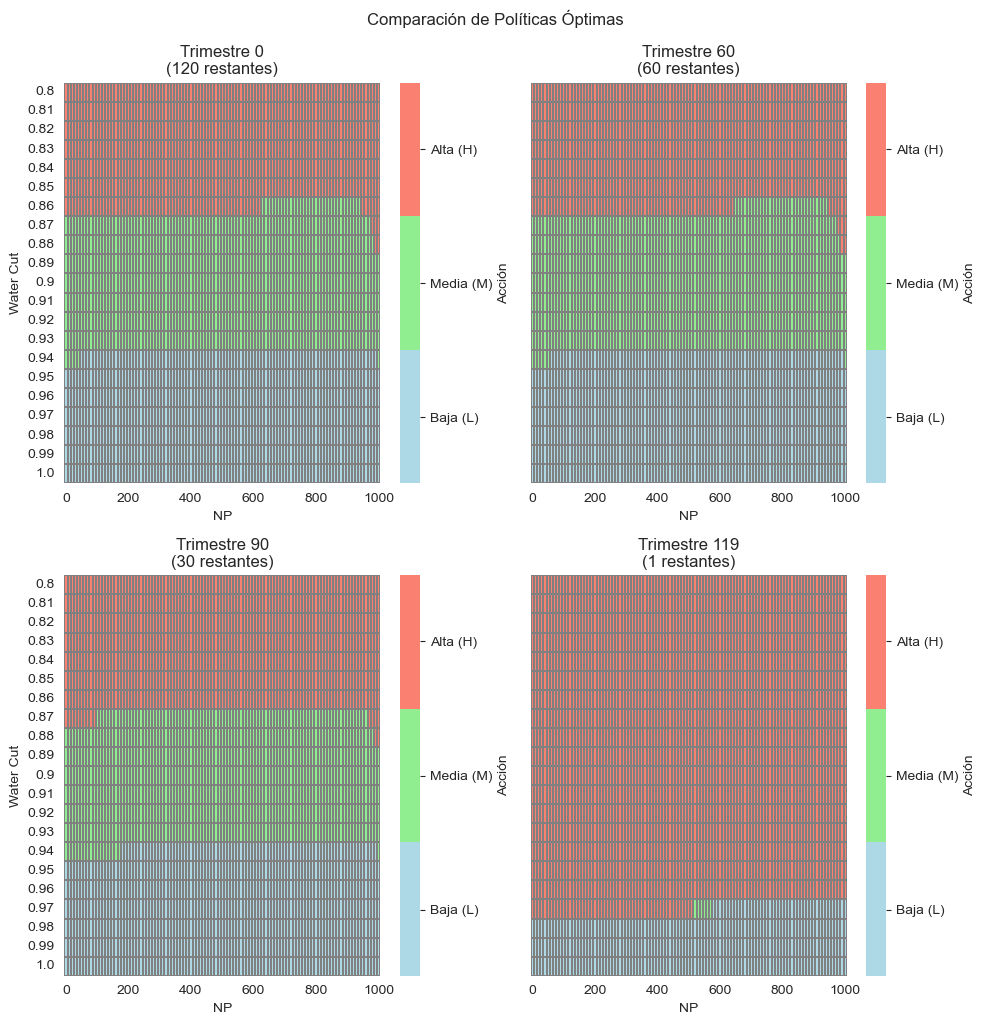

In [90]:
# Ejecutar primero la iteración de valor finito
V, pi = iteracion_valor_finito(modelo, horizonte=120)

# Visualizar la política al inicio, mitad y final del horizonte
visualizar_politica_tiempo(modelo, pi, tiempo=0)      # Al inicio
visualizar_politica_tiempo(modelo, pi, tiempo=80)     # A mitad del horizonte
visualizar_politica_tiempo(modelo, pi, tiempo=119)    # Al final del horizonte

# Comparar políticas en momentos clave del horizonte
comparar_politicas_tiempos(modelo, pi, [0, 60, 90, 119])

### Guardo estado del notebook para continuar luego

In [121]:
# Guardar todas las variables relevantes en un diccionario
checkpoint = {
    # Políticas
    'pi_opt_ql': pi_opt_ql,
    'pi_opt_ql_2': pi_opt_ql_2,
    'pi_opt_ql_zero': pi_opt_ql_zero,
    'pi_opt_valor': pi_opt_valor,
    'pi_opt_politica': pi_opt_politica,

    # Valores Q
    'Q_opt_ql': Q_opt_ql,
    'Q_opt_ql_2': Q_opt_ql_2,
    'Q_opt_ql_zero': Q_opt_ql_zero,

    # Funciones de valor V
    'V_opt_valor': V_opt_valor,
    'V_opt_politica': V_opt_politica,

    # Resultados Q-learning acumulativo
    'resultados_q': resultados_q,
    'df_q_hist': df_q_hist,
    'resultados_q_zeros': resultados_q_zeros,
    'df_q_hist_zeros': df_q_hist_zeros,

    # Modelo y parámetros
    'modelo': modelo,
    'probas_np': probas_np,
    'probas_wc': probas_wc,
    'tita': tita,
    'alpha': alpha,
    'p_oil': p_oil,
    'np_resolution': np_resolution,
    'max_np': max_np,

    # Espacio de estados y acciones
    's': s,
    'a': a,
    'np_values': np_values,
    'wc_values': wc_values,

    # Hiperparámetros y resultados
    'epsilons': epsilons,
    'iters': iters,
    'max_iters': max_iters,
    'tiempo': tiempo,
    'valor_q': valor_q,
    'pct_coincidencias': pct_coincidencias,
    'resultados': resultados,

    # Variables de tiempo finito (si existen)
    'V': V if 'V' in globals() else None,
    'pi': pi if 'pi' in globals() else None
}

# Guardar en un archivo
joblib.dump(checkpoint, 'estado_notebook_rl.joblib')### Guardo memoria en pkk

['estado_notebook_rl.joblib']